# Assignment:02 ANN & Deep Learning
### Resnet and Unet

| | |
|---|---|
| **Name** | ______________________________ |
| **Roll No.** | ______________________________ |

---


>
> **Grading (100 marks)**
>
> | Part | Marks |
> |---|---:|
> | Dataset setup, exploration, preprocessing, split (Tasks 1-4, 12-14) | 20 |
> | ResNet-50 modification, training and evaluation (Tasks 5-11) | 25 |
> | U-Net loss, metrics, training and evaluation (Tasks 15-20) | 25 |
> | Results tables (Task 21) and filled-in reports | 5 |
> | Discussion questions and conclusion | 15 |
> | GitHub repository, README, code quality / comments | 10 |

# Table of Contents
1. Introduction
2. Learning Objectives
3. Datasets - where to download them and how to upload them to Google Drive
4. **Step 1** - Environment setup (libraries, GPU, reproducibility)
5. **Step 2** - Mount Google Drive and set the dataset paths
6. **Part A - ResNet-50 Fine-Tuning (Classification)**
    * Step 3 - Explore the flower dataset
    * Step 4 - Preprocessing, augmentation and train/validation/test split
    * Step 5 - ResNet-50 architecture and loading the pretrained model
    * Step 6 - Training utilities
    * Step 7 - Phase 1: feature extraction (frozen backbone)
    * Step 8 - Phase 2: fine-tuning (unfreeze `layer4`)
    * Step 9 - Training curves
    * Step 10 - Evaluation on the test set
7. **Part B - U-Net Fine-Tuning (Segmentation)**
    * Step 11 - Explore the pet segmentation dataset
    * Step 12 - Joint image/mask preprocessing, split and loaders
    * Step 13 - U-Net architecture and model creation
    * Step 14 - Loss function and metrics
    * Step 15 - Phase 1: train the decoder (frozen encoder)
    * Step 16 - Phase 2: fine-tune the encoder
    * Step 17 - Evaluation and visualization






# Introduction
Training a deep convolutional network from scratch needs **tens of thousands of labelled images** and a lot of compute. In practice (medical imaging, agriculture, small company datasets) we often have only **100-200 images**. In such cases we rely on **transfer learning**: we start from a network that was already trained on a very large dataset (ImageNet, 1.2 million images) and **adapt** it to our own small dataset. This adaptation step is called **fine-tuning**.

In this assignment you will fine-tune two of the most important CNN families in computer vision:

| Model | Task | Idea |
|---|---|---|
| **ResNet-50** | Image **classification** (what is in the image?) | Deep CNN with *residual (skip) connections* and bottleneck blocks |
| **U-Net** (with a ResNet-50 encoder) | Image **segmentation** (which pixels belong to the object?) | Encoder-decoder network with *skip connections* between encoder and decoder |



# Datasets (Download -> Upload to Google Drive)

Use **two small datasets** (about **100-200 images** each).

| | Dataset 1 (classification) | Dataset 2 (segmentation) |
|---|---|---|
| **Name** | Oxford Flowers-102 (small subset) | Oxford-IIIT Pet (small subset) |
| **Official page / download** | https://www.robots.ox.ac.uk/~vgg/data/flowers/102/ | https://www.robots.ox.ac.uk/~vgg/data/pets/ |
| **Files** | `102flowers.tgz`, `imagelabels.mat` | `images.tar.gz`, `annotations.tar.gz` |
| **Size to use** | 5 classes x 40 images = **200 images** | **150 image + mask pairs** |
| **Used by** | ResNet-50 | U-Net |


### Required folder structure on Google Drive
```text
MyDrive/
└── ANN_DL_Assignment/
    ├── flowers_subset/              <- classification dataset (ImageFolder format)
    │   ├── flower_class_000/  *.jpg
    │   ├── flower_class_001/  *.jpg
    │   └── ...
    └── pets_subset/                 <- segmentation dataset
        ├── images/   *.jpg
        └── masks/    *.png          <- same file name as the image
```
For the pet masks, the original *trimap* convention is kept: `1 = pet`, `2 = background`, `3 = border`.


# Step 1: Environment Setup
**Before running:** in Colab choose **Runtime -> Change runtime type -> T4 GPU**. Training ResNet-50 and U-Net on a CPU is very slow.

We install `segmentation-models-pytorch` (SMP), which provides U-Net with pretrained encoders, and import all libraries. We also fix the random seeds so that results are **reproducible**.

In [1]:
# Install the segmentation library (U-Net with pretrained encoders)
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00


In [2]:
# ---------------- Standard libraries ----------------
import os, random, shutil, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ---------------- PyTorch ----------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, models, transforms
import torchvision.transforms.functional as TF

# ---------------- Scikit-learn (splitting + metrics) ----------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support)

# ---------------- U-Net library ----------------
import segmentation_models_pytorch as smp

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Using device    :", device)
if device.type == "cpu":
    print("WARNING: no GPU found. Go to Runtime > Change runtime type > T4 GPU.")



PyTorch version : 2.11.0+cu130
Using device    : cuda


In [3]:
# ImageNet statistics: pretrained models expect inputs normalized with them
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Step 2: Mount Google Drive and Set Paths
Colab's local disk is erased when the runtime restarts. **Google Drive** keeps the datasets and trained models permanently. After running the cell below, Google asks for permission to access your Drive - click **Allow**.

In [4]:
from google.colab import drive

# Mount Google Drive at /content/drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ---------------- Paths (change BASE_DIR if your folder has a different name) ----------------
BASE_DIR     = "/content/drive/MyDrive/ANN_DL_Assignment"      # main assignment folder on Drive
FLOWERS_DIR  = os.path.join(BASE_DIR, "flowers_subset")    # classification dataset
PETS_DIR     = os.path.join(BASE_DIR, "pets_subset")       # segmentation dataset
PET_IMG_DIR  = os.path.join(PETS_DIR, "images")
PET_MASK_DIR = os.path.join(PETS_DIR, "masks")
CKPT_DIR     = os.path.join(BASE_DIR, "checkpoints")       # trained weights are saved here (Drive)
RESULTS_DIR  = "/content/results"                          # figures/tables (copied to Drive at the end)

for d in [BASE_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
print("Base folder exists:", os.path.isdir(BASE_DIR))

Base folder exists: True


### Step 2b: Download and prepare the datasets (5 flower classes x 40 images, 150 pet pairs)
The two Google Drive files are the **raw** Oxford archives (`102flowers.tgz`, Pet `images.tar.gz`). They contain no labels,
so this cell also downloads the two small label files from the official Oxford VGG site and then builds the subsets
required by the assignment:

| Dataset | Images from Drive | Labels from Oxford VGG | Subset built |
|---|---|---|---|
| Flowers-102 | `102flowers.tgz` | `imagelabels.mat` (class id of every image) | **5 classes x 40 images = 200 images** (real species names) |
| Oxford-IIIT Pet | `images.tar.gz` | `annotations.tar.gz` (trimap masks) | **150 image + mask pairs**, spread evenly over all 37 breeds |

The class of every flower image is read from `imagelabels.mat`; the first 5 classes are used
(pink primrose, hard-leaved pocket orchid, canterbury bells, sweet pea, english marigold).
The pet breed is detected from the file name (`<Breed>_<number>`; cat breeds start with a capital letter).

The subsets are stored on Colab's **local disk** (`/content/data`, fast reading during training) with the shorter image side
resized to `PRE_RESIZE = 320` px (masks with NEAREST, so the trimap values 1/2/3 stay intact). A copy is written to
`MyDrive/ANN_DL_Assignment/flowers_subset` and `pets_subset` (required folder structure) in the background.
Re-running the cell skips everything that is already prepared.

In [6]:
!pip install -q gdown
import gdown, tarfile, glob, json, re, threading, urllib.request
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from scipy.io import loadmat

# ===================== Dataset configuration =====================
FLOWER_CLASSES   = 5      # number of flower classes (assignment: 5)
FLOWER_PER_CLASS = 40     # images per flower class   (assignment: 40 -> 200 images)
PET_TOTAL        = 150    # image/mask pairs, spread evenly over all breeds (assignment: 150)
PRE_RESIZE       = 320    # shorter side (pixels) of the stored copies -> fast data loading
SAVE_TO_DRIVE    = True   # also copy the prepared subsets to MyDrive/ANN_DL_Assignment (background thread)
CONFIG = dict(FLOWER_CLASSES=FLOWER_CLASSES, FLOWER_PER_CLASS=FLOWER_PER_CLASS,
              PET_TOTAL=PET_TOTAL, PRE_RESIZE=PRE_RESIZE, SEED=SEED)

# Shared Google Drive files (raw Oxford archives)
FILE_IDS = {"flowers": "1-YeU6w5VXTI2WlFpOzL6Gx7QFz99APBN",     # 102flowers.tgz
            "pets":    "1UdqsFa5TRYzz6V_PWjNCIMoaI9-gefkp"}     # images.tar.gz
# Label files that are not inside the shared archives (official Oxford VGG sources, mirror first)
OFFICIAL = {
    "imagelabels.mat":    ["https://thor.robots.ox.ac.uk/datasets/flowers-102/imagelabels.mat",
                           "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"],
    "annotations.tar.gz": ["https://thor.robots.ox.ac.uk/datasets/pets/annotations.tar.gz",
                           "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"],
}

DL_DIR, RAW_DIR, LOCAL_DATA = "/content/downloads", "/content/raw", "/content/data"
# Working copies on the fast local disk (these variables replace the Drive paths of Step 2 for training)
FLOWERS_DIR  = os.path.join(LOCAL_DATA, "flowers_subset")
PETS_DIR     = os.path.join(LOCAL_DATA, "pets_subset")
PET_IMG_DIR  = os.path.join(PETS_DIR, "images")
PET_MASK_DIR = os.path.join(PETS_DIR, "masks")
for d in [DL_DIR, RAW_DIR, LOCAL_DATA]:
    os.makedirs(d, exist_ok=True)

# Official names of the 102 Oxford flower classes (label id 1..102)
FLOWER_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea", "english marigold",
    "tiger lily", "moon orchid", "bird of paradise", "monkshood", "globe thistle", "snapdragon", "colt's foot",
    "king protea", "spear thistle", "yellow iris", "globe-flower", "purple coneflower", "peruvian lily",
    "balloon flower", "giant white arum lily", "fire lily", "pincushion flower", "fritillary", "red ginger",
    "grape hyacinth", "corn poppy", "prince of wales feathers", "stemless gentian", "artichoke", "sweet william",
    "carnation", "garden phlox", "love in the mist", "mexican aster", "alpine sea holly", "ruby-lipped cattleya",
    "cape flower", "great masterwort", "siam tulip", "lenten rose", "barbeton daisy", "daffodil", "sword lily",
    "poinsettia", "bolero deep blue", "wallflower", "marigold", "buttercup", "oxeye daisy", "common dandelion",
    "petunia", "wild pansy", "primula", "sunflower", "pelargonium", "bishop of llandaff", "gaura", "geranium",
    "orange dahlia", "pink-yellow dahlia", "cautleya spicata", "japanese anemone", "black-eyed susan",
    "silverbush", "californian poppy", "osteospermum", "spring crocus", "bearded iris", "windflower",
    "tree poppy", "gazania", "azalea", "water lily", "rose", "thorn apple", "morning glory", "passion flower",
    "lotus", "toad lily", "anthurium", "frangipani", "clematis", "hibiscus", "columbine", "desert-rose",
    "tree mallow", "magnolia", "cyclamen", "watercress", "canna lily", "hippeastrum", "bee balm", "ball moss",
    "foxglove", "bougainvillea", "camellia", "mallow", "mexican petunia", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily"]

def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

def extract_tar(path, dest):
    os.makedirs(dest, exist_ok=True)
    with tarfile.open(path) as t:
        if hasattr(tarfile, "data_filter"): t.extractall(dest, filter="data")
        else: t.extractall(dest)

def find_dir(root, pred):
    for r, dirs, files in os.walk(root):
        if pred(r, files): return r
    return None

def find_file(root, name):
    hits = glob.glob(os.path.join(root, "**", name), recursive=True)
    return hits[0] if hits else None

def download_raw(key):
    # Download one shared Drive archive and extract it (skipped if already extracted).
    dest = os.path.join(RAW_DIR, key)
    if os.path.isdir(dest) and os.listdir(dest): return dest
    path = gdown.download(id=FILE_IDS[key], output=DL_DIR + "/", quiet=False)
    extract_tar(path, dest); os.remove(path)
    return dest

def fetch_official(name):
    out = os.path.join(DL_DIR, name)
    if os.path.exists(out) and os.path.getsize(out) > 0: return out
    for url in OFFICIAL[name]:
        try:
            urllib.request.urlretrieve(url, out); print("Downloaded", url); return out
        except Exception as e:
            print("Failed:", url, "->", e)
    raise RuntimeError(f"Could not download {name}. Download it manually and upload it to {DL_DIR}.")

def resize_short(img, size, resample):
    # Resize so that the shorter side == size (only shrinks, keeps aspect ratio).
    w, h = img.size
    if min(w, h) <= size: return img
    r = size / min(w, h)
    return img.resize((max(1, round(w * r)), max(1, round(h * r))), resample)

def subset_ok(path):
    info = os.path.join(path, "_info.json")
    return os.path.exists(info) and json.load(open(info)) == CONFIG

def write_info(path):
    json.dump(CONFIG, open(os.path.join(path, "_info.json"), "w"))

def run_parallel(fn, jobs):
    with ThreadPoolExecutor(8) as ex:
        return list(ex.map(fn, jobs))

def build_flowers():
    raw = download_raw("flowers")
    jpg_dir = os.path.dirname(find_file(raw, "image_00001.jpg"))
    labels = loadmat(fetch_official("imagelabels.mat"))["labels"].ravel().astype(int)   # label of image_{i+1:05d}.jpg
    classes = sorted(set(labels.tolist()))                     # every class present in the label file
    if FLOWER_CLASSES: classes = classes[:FLOWER_CLASSES]
    jobs = []
    for c in classes:
        folder = os.path.join(FLOWERS_DIR, f"{c:03d}_{slug(FLOWER_NAMES[c - 1])}")
        os.makedirs(folder, exist_ok=True)
        idx = np.where(labels == c)[0]
        if FLOWER_PER_CLASS: idx = idx[:FLOWER_PER_CLASS]
        jobs += [(os.path.join(jpg_dir, f"image_{i + 1:05d}.jpg"), os.path.join(folder, f"image_{i + 1:05d}.jpg"))
                 for i in idx]
    def work(job):
        s, d = job
        resize_short(Image.open(s).convert("RGB"), PRE_RESIZE, Image.BICUBIC).save(d, quality=95)
    run_parallel(work, jobs)
    write_info(FLOWERS_DIR)

def build_pets():
    raw = download_raw("pets")
    is_img_dir = lambda r, files: os.path.basename(r) == "images" and any(f.endswith(".jpg") for f in files)
    img_dir = find_dir(raw, is_img_dir)
    is_tri = lambda r, files: os.path.basename(r) == "trimaps"
    tri_dir = find_dir(raw, is_tri) or find_dir(RAW_DIR, is_tri)
    if tri_dir is None:
        extract_tar(fetch_official("annotations.tar.gz"), os.path.join(RAW_DIR, "pet_annotations"))
        tri_dir = find_dir(RAW_DIR, is_tri)
    jpg   = {os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith(".jpg")}
    png   = {os.path.splitext(f)[0] for f in os.listdir(tri_dir) if f.endswith(".png") and not f.startswith("._")}
    stems = sorted(jpg & png)
    by_breed = defaultdict(list)                               # breed = file name without the trailing number
    for s in stems:
        by_breed[s.rsplit("_", 1)[0]].append(s)
    # take PET_TOTAL pairs round-robin over the breeds -> every breed is represented (about 4 pairs each)
    rng = random.Random(SEED)
    pools = {b: rng.sample(lst, len(lst)) for b, lst in sorted(by_breed.items())}
    order = list(pools); rng.shuffle(order)
    chosen, k = [], 0
    while len(chosen) < min(PET_TOTAL, len(stems)):
        b = order[k % len(order)]
        if pools[b]: chosen.append(pools[b].pop())
        k += 1
    os.makedirs(PET_IMG_DIR, exist_ok=True); os.makedirs(PET_MASK_DIR, exist_ok=True)
    def work(s):
        try:
            img  = Image.open(os.path.join(img_dir, s + ".jpg")).convert("RGB")
            mask = Image.open(os.path.join(tri_dir, s + ".png"))
            resize_short(img,  PRE_RESIZE, Image.BICUBIC).save(os.path.join(PET_IMG_DIR, s + ".jpg"), quality=95)
            resize_short(mask, PRE_RESIZE, Image.NEAREST).save(os.path.join(PET_MASK_DIR, s + ".png"))   # labels kept
            return True
        except Exception as e:
            print("skipped (unreadable):", s, e); return False
    ok = run_parallel(work, chosen)
    write_info(PETS_DIR)
    print(f"Pets: {len(by_breed)} breeds detected, {sum(ok)} pairs prepared")

for path, builder, name in [(FLOWERS_DIR, build_flowers, "flowers"), (PETS_DIR, build_pets, "pets")]:
    if subset_ok(path):
        print(f"{name}: already prepared - skipped")
    else:
        shutil.rmtree(path, ignore_errors=True)
        print(f"{name}: preparing ...")
        t0 = time.time(); builder(); print(f"{name}: done in {time.time() - t0:.0f}s")

n_fl_cls = len([d for d in os.listdir(FLOWERS_DIR) if os.path.isdir(os.path.join(FLOWERS_DIR, d))])
n_fl_img = sum(len(files) for _, _, files in os.walk(FLOWERS_DIR)) - 1
print(f"Flowers: {n_fl_cls} classes, {n_fl_img} images  ->", FLOWERS_DIR)
print(f"Pets   : {len(os.listdir(PET_IMG_DIR))} images / {len(os.listdir(PET_MASK_DIR))} masks  ->", PETS_DIR)

# Copy the prepared subsets to Google Drive in the background (required folder structure)
def copy_to_drive():
    for local, name in [(FLOWERS_DIR, "flowers_subset"), (PETS_DIR, "pets_subset")]:
        dst = os.path.join(BASE_DIR, name)
        if subset_ok(dst): continue
        shutil.rmtree(dst, ignore_errors=True)
        shutil.copytree(local, dst, ignore=shutil.ignore_patterns("_info.json"))
        shutil.copy(os.path.join(local, "_info.json"), dst)      # written last = copy complete
    print("\n[background] Subsets copied to Google Drive:", BASE_DIR)

if SAVE_TO_DRIVE:
    threading.Thread(target=copy_to_drive, daemon=True).start()

flowers: preparing ...


Downloading...
From (original): https://drive.google.com/uc?id=1-YeU6w5VXTI2WlFpOzL6Gx7QFz99APBN
From (redirected): https://drive.google.com/uc?id=1-YeU6w5VXTI2WlFpOzL6Gx7QFz99APBN&confirm=t&uuid=d0f10b47-4d4c-4a52-ba78-4e6748544427
To: /content/downloads/102flowers.tgz
100%|██████████| 345M/345M [00:02<00:00, 130MB/s]


Downloaded https://thor.robots.ox.ac.uk/datasets/flowers-102/imagelabels.mat
flowers: done in 15s
pets: preparing ...


Downloading...
From (original): https://drive.google.com/uc?id=1UdqsFa5TRYzz6V_PWjNCIMoaI9-gefkp
From (redirected): https://drive.google.com/uc?id=1UdqsFa5TRYzz6V_PWjNCIMoaI9-gefkp&confirm=t&uuid=afda1493-3225-4e37-a53a-a823ae3733ac
To: /content/downloads/images.tar.gz
100%|██████████| 792M/792M [00:10<00:00, 74.7MB/s]


Downloaded https://thor.robots.ox.ac.uk/datasets/pets/annotations.tar.gz
Pets: 37 breeds detected, 150 pairs prepared
pets: done in 28s
Flowers: 5 classes, 200 images  -> /content/data/flowers_subset
Pets   : 150 images / 150 masks  -> /content/data/pets_subset


---
# PART A - ResNet-50 Fine-Tuning (Classification)
---
# Step 3: Explore the Flower Dataset
Always inspect your data before training: how many images, how many classes, is the dataset balanced, what do images look like, and what sizes do they have?

### Task 1 — Count and plot the images (Step 3)
Complete the cell below.

1. **(1a)** Fill the dictionary `counts` so that it maps each class folder name to its number of images. *Hint:* `os.listdir(os.path.join(FLOWERS_DIR, c))` lists the files of class `c`.
2. **(1b)** Print the number of classes, the total number of images, and the images per class.
3. **(1c)** Draw a bar chart of the class distribution with `plt.bar`.

**Report:** number of classes = ______ , total number of images = ______

Number of classes     : 5
Total number of images: 200
Images per class      : min 40, max 40, mean 40.0
  001_pink_primrose               : 40
  002_hard_leaved_pocket_orchid   : 40
  003_canterbury_bells            : 40
  004_sweet_pea                   : 40
  005_english_marigold            : 40


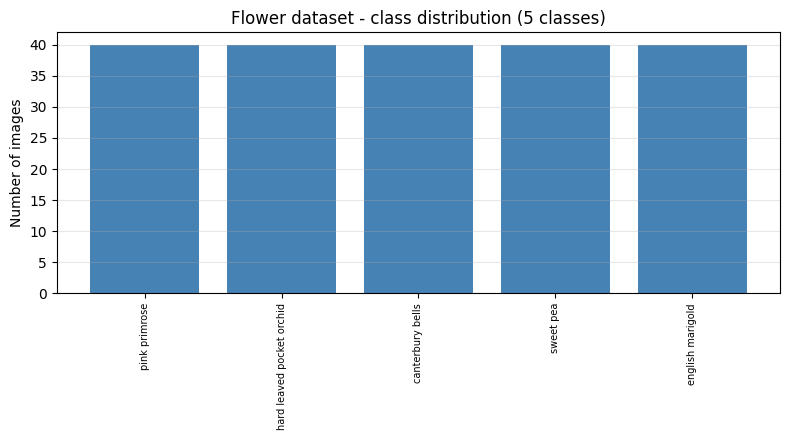

REPORT -> number of classes = 5 , total number of images = 200


In [7]:
IMG_EXT = (".jpg", ".jpeg", ".png")

def pretty(c):
    # "001_pink_primrose" -> "pink primrose"
    return c.split("_", 1)[1].replace("_", " ") if "_" in c else c

# List of class folders (given)
class_dirs = sorted(d for d in os.listdir(FLOWERS_DIR) if os.path.isdir(os.path.join(FLOWERS_DIR, d)))

# (1a) counts = {class_name: number_of_images}
counts = {}
for c in class_dirs:
    counts[c] = len([f for f in os.listdir(os.path.join(FLOWERS_DIR, c)) if f.lower().endswith(IMG_EXT)])

# (1b) print number of classes, total images and images per class
n_vals = np.array(list(counts.values()))
print("Number of classes     :", len(counts))
print("Total number of images:", n_vals.sum())
print(f"Images per class      : min {n_vals.min()}, max {n_vals.max()}, mean {n_vals.mean():.1f}")
for c, n in counts.items():
    print(f"  {c:32s}: {n}")

# (1c) bar chart of the class distribution
plt.figure(figsize=(max(8, 0.18 * len(counts)), 4.5))
plt.bar(range(len(counts)), n_vals, color="steelblue")
step = 1 if len(counts) <= 20 else 5
plt.xticks(range(0, len(counts), step), [pretty(c) for c in class_dirs][::step], rotation=90, fontsize=7)
plt.ylabel("Number of images"); plt.title(f"Flower dataset - class distribution ({len(counts)} classes)")
plt.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "flowers_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"REPORT -> number of classes = {len(counts)} , total number of images = {n_vals.sum()}")

### Task 2 — Show one sample per class (Step 3)
For every class display **one image** with its **class name** and **size (width x height)** in the title.
*Hint:* `Image.open(path).convert("RGB")` gives a PIL image; `img.size` gives `(width, height)`.

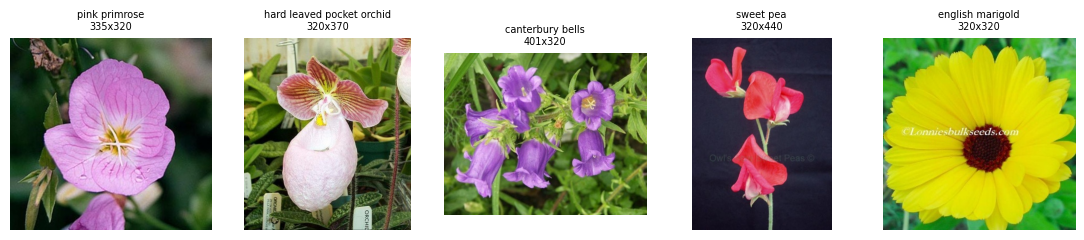

In [8]:
# One sample per class in a grid (works for 5 or 102 classes)
cols = min(10, len(class_dirs))
rows = int(np.ceil(len(class_dirs) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.5 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, class_dirs):
    # 1) take the first file name inside the class folder c
    first = sorted(f for f in os.listdir(os.path.join(FLOWERS_DIR, c)) if f.lower().endswith(IMG_EXT))[0]
    # 2) open the image and convert it to RGB
    img = Image.open(os.path.join(FLOWERS_DIR, c, first)).convert("RGB")
    # 3) show it with class name and size (width x height)
    ax.imshow(img)
    ax.set_title(f"{pretty(c)}\n{img.size[0]}x{img.size[1]}", fontsize=7)
for ax in axes:
    ax.axis("off")

plt.tight_layout(); plt.show()

# Step 4: Preprocessing, Augmentation and Data Split

### Why preprocessing?
```text
Original image -> Resize (224x224) -> Augmentation (train only) -> ToTensor -> Normalize (ImageNet mean/std) -> Model
```
* **Resize:** a CNN with a fixed classifier needs a fixed input size (224x224 for ResNet).
* **Augmentation:** random flips/rotations/colour changes create "new" images every epoch. This is the most important regulariser for small datasets. **Never augment validation/test images**, otherwise evaluation becomes noisy.
* **Normalization:** pretrained weights were learned with ImageNet-normalized inputs, so we must use the same mean/std.

### Data split (stratified)
```text
70% Training   -> the model learns from it
15% Validation -> monitor overfitting, pick the best epoch / hyper-parameters
15% Test       -> used ONCE at the end for the final, unbiased score
```
*Stratified* means every class keeps the same proportion in each subset.

### Task 3 — Build the transformation pipelines (Step 4)
Complete `train_tf` with **four** parts, in this order, and `eval_tf` **without augmentation**:

| Part | Transform | Notes |
|---|---|---|
| 1 | Resize | to `(IMG_SIZE, IMG_SIZE)` |
| 2 | Augmentation | random horizontal flip, random rotation (15 degrees), colour jitter (brightness/contrast/saturation 0.2) |
| 3 | Tensor | `transforms.ToTensor()` |
| 4 | Normalize | with `IMAGENET_MEAN`, `IMAGENET_STD` |

*Question to think about:* why must `eval_tf` not contain random augmentation?

In [9]:
IMG_SIZE = 224

train_tf = transforms.Compose([
    # (1) Resize
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # (2) Augmentation (training only)
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.9, 1.1)),   # extra: random zoom
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

    # (3) Convert to tensor (values in [0, 1], shape C x H x W)
    transforms.ToTensor(),

    # (4) Normalize with the ImageNet statistics
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Evaluation transform: resize + tensor + normalize (NO augmentation -> deterministic evaluation)
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### Task 4 — Stratified 70/15/15 split and DataLoaders (Step 4)
The two `ImageFolder` objects point to the **same files**: one applies augmentation (`train_tf`), the other does not (`eval_tf`). Complete the following:

* **(4a)** Split the **indices** with `train_test_split` (called twice): 70% train / 30% temp, then split temp 50/50 into validation and test. Use `stratify=` and `random_state=SEED` so every class keeps its proportion.
* **(4b)** Create the four `Subset` objects: `train_ds` (augmented), `train_eval_ds` (train indices but *without* augmentation, used only to measure training accuracy), `val_ds`, `test_ds`.
* **(4c)** Create the four `DataLoader`s (`BATCH = 16`): `train_loader` (shuffle=True), `train_eval_loader`, `val_loader`, `test_loader` (shuffle=False, `num_workers=2`).
* Print the size of each subset.

In [10]:
full_train = datasets.ImageFolder(FLOWERS_DIR, transform=train_tf)   # with augmentation
full_eval  = datasets.ImageFolder(FLOWERS_DIR, transform=eval_tf)    # without augmentation
class_names = full_train.classes
num_classes = len(class_names)
targets     = np.array(full_train.targets)
all_idx     = np.arange(len(targets))
print(f"Classes detected: {num_classes}")
print([pretty(c) for c in class_names])

# (4a) train_idx, val_idx, test_idx  (stratified 70/15/15)
train_idx, temp_idx = train_test_split(all_idx, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)

# (4b) train_ds, train_eval_ds, val_ds, test_ds
train_ds      = Subset(full_train, train_idx)   # augmented -> used for learning
train_eval_ds = Subset(full_eval,  train_idx)   # same images, no augmentation -> training accuracy
val_ds        = Subset(full_eval,  val_idx)
test_ds       = Subset(full_eval,  test_idx)

# (4c) train_loader, train_eval_loader, val_loader, test_loader
BATCH = 16
loader_kw = dict(num_workers=2, pin_memory=True, persistent_workers=True)
train_loader      = DataLoader(train_ds,      batch_size=BATCH, shuffle=True,  **loader_kw)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH, shuffle=False, **loader_kw)
val_loader        = DataLoader(val_ds,        batch_size=BATCH, shuffle=False, **loader_kw)
test_loader       = DataLoader(test_ds,       batch_size=BATCH, shuffle=False, **loader_kw)

# print the size of train / validation / test
print(f"Train: {len(train_ds)} | Validation: {len(val_ds)} | Test: {len(test_ds)}")
print("Min images per class in train / val / test:",
      [int(np.bincount(targets[i], minlength=num_classes).min()) for i in (train_idx, val_idx, test_idx)])

Classes detected: 5
['pink primrose', 'hard leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold']
Train: 140 | Validation: 30 | Test: 30
Min images per class in train / val / test: [28, 6, 6]


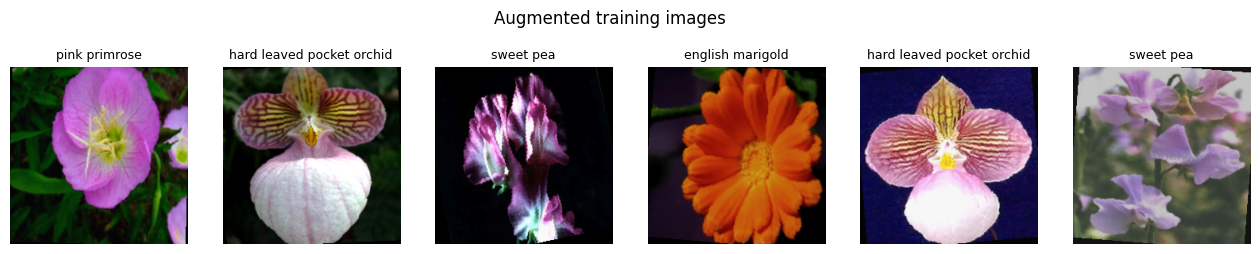

In [11]:
# ---- Visualize augmented training samples ----
MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
STD_T  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(t):
    # Undo ImageNet normalization so that a tensor can be displayed.
    return (t.cpu() * STD_T + MEAN_T).clamp(0, 1).permute(1, 2, 0).numpy()

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for ax, im, lb in zip(axes, imgs[:6], labels[:6]):
    ax.imshow(denorm(im)); ax.set_title(pretty(class_names[int(lb)]), fontsize=9); ax.axis("off")
plt.suptitle("Augmented training images"); plt.show()

# Step 5: ResNet-50 Architecture and Pretrained Model

### Why residual connections?
Very deep plain CNNs become *harder* to train (vanishing gradients, the "degradation problem"). ResNet adds a **skip (identity) connection** so each block learns a *residual* `F(x)` and outputs `F(x) + x`. Gradients flow directly through the shortcut, which makes networks with 50, 101 or 152 layers trainable.

### ResNet-50 overview
```text
Input 224x224x3
   |
7x7 Conv, stride 2 + BatchNorm + ReLU + 3x3 MaxPool
   |
layer1 : 3  bottleneck blocks   (256  channels)
layer2 : 4  bottleneck blocks   (512  channels)
layer3 : 6  bottleneck blocks   (1024 channels)
layer4 : 3  bottleneck blocks   (2048 channels)
   |
Global Average Pooling
   |
Fully connected (fc): 2048 -> 1000 (ImageNet)   <-- we REPLACE this layer
```

### Bottleneck residual block (used by ResNet-50)
```text
x ──────────────────────────────┐   (skip connection; 1x1 conv if shape changes)
│                               │
1x1 Conv (reduce channels) + BN + ReLU
│                               │
3x3 Conv                    + BN + ReLU
│                               │
1x1 Conv (expand channels) + BN
│                               │
└──────────── (+) Addition ◄────┘
               │
              ReLU
```
The 1x1 convolutions reduce and then restore the number of channels, so the expensive 3x3 convolution works on fewer channels (this is the "bottleneck").

### Fine-tuning strategy (2 phases)
```text
ImageNet-pretrained ResNet-50
        |
Replace fc layer (1000 -> number of flower classes)
        |
PHASE 1 - Feature extraction: freeze the whole backbone, train only fc   (lr = 1e-3)
        |
PHASE 2 - Fine-tuning: unfreeze layer4 (+ fc), continue with a smaller lr (lr = 1e-4)
        |
Final model
```
Early layers learn *generic* features (edges, colours, textures); the last layers learn *task-specific* features. Therefore we adapt the last layers first and keep the early ones.

### Task 5 — Modify the ResNet-50 classifier (Step 5)
The pretrained model has a final fully-connected layer `fc` with **1000 outputs** (ImageNet classes). Replace it so that the network predicts **your** `num_classes` flower classes.

1. Read the number of input features of the old layer (`resnet.fc.in_features`).
2. Assign a new `nn.Linear(in_features, num_classes)` to `resnet.fc`.

In [12]:
# Load ResNet-50 pretrained on ImageNet (given)
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print("Original classifier:", resnet.fc)

# Find the number of input features of the old classifier (2048 for ResNet-50)
in_features = resnet.fc.in_features

# Replace the final layer: 2048 -> number of detected flower classes
# (a small dropout before the linear layer regularises the new head)
resnet.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(in_features, num_classes))

resnet = resnet.to(device)
print("New classifier     :", resnet.fc)

def count_params(model):
    # Return (total parameters, trainable parameters).
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, train

print("Total / trainable parameters:", count_params(resnet))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Original classifier: Linear(in_features=2048, out_features=1000, bias=True)
New classifier     : Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=5, bias=True)
)
Total / trainable parameters: (23518277, 23518277)


# Step 6: Training Utilities
We write the training code **once** and reuse it for both phases.

* `run_epoch_cls` - one pass over a loader. If an optimizer is given it trains, otherwise it evaluates (no gradients).
* `keep_frozen_bn_eval` - **important detail:** `model.train()` also updates the running mean/variance of **BatchNorm** layers, even when their weights are frozen. With a tiny dataset this would corrupt the pretrained statistics, so we keep frozen BatchNorm layers in evaluation mode.
* `fit_cls` - trains for several epochs, records the history and **saves the best model** (highest validation accuracy) to Google Drive.

In [13]:
def keep_frozen_bn_eval(model):
    # Put BatchNorm layers whose parameters are frozen into eval mode (given).
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
            m.eval()

### Task 6 — Write the training function `run_epoch_cls` (Step 6)
The function performs **one epoch** over a loader. If an `optimizer` is passed it **trains**, otherwise it only **evaluates**. Inside the loop implement:

1. Move `images` and `labels` to `device`.
2. Forward pass: `outputs = model(images)`.
3. Compute `loss = criterion(outputs, labels)`.
4. **If training:** `optimizer.zero_grad()` -> `loss.backward()` -> `optimizer.step()`.
5. Accumulate `total_loss` (loss x batch size), `correct` (number of correct predictions, use `outputs.argmax(1)`) and `n` (number of samples).

Also define `criterion` (the loss for multi-class classification).

In [14]:
# Mixed precision (AMP): ~2x faster on a T4 GPU, same accuracy
USE_AMP = device.type == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=USE_AMP)
torch.backends.cudnn.benchmark = True

def run_epoch_cls(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)                  # train mode or eval mode
    if training:
        keep_frozen_bn_eval(model)
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(training): # gradients only while training
        for images, labels in loader:
            # 1) move the batch to the GPU / CPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            # 2) forward pass + 3) loss (in mixed precision)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)
            # 4) backward pass + update (training only)
            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            # 5) statistics
            k = images.size(0)
            total_loss += loss.item() * k
            correct    += (outputs.argmax(1) == labels).sum().item()
            n          += k

    return total_loss / n, correct / n

# Loss function for multi-class classification (label smoothing reduces over-confidence with many classes)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [15]:
# Given (extended with early stopping): records the history and saves the BEST model on Google Drive
cls_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
cls_phase_end = []

def fit_cls(model, optimizer, epochs, ckpt_path, scheduler=None, patience=5):
    best_acc, best_loss, wait = -1.0, float("inf"), 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch_cls(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch_cls(model, val_loader, criterion)
        if scheduler: scheduler.step()
        for k, v in zip(cls_history, [tr_loss, va_loss, tr_acc, va_acc]):
            cls_history[k].append(v)
        improved = va_acc > best_acc or (va_acc == best_acc and va_loss < best_loss)
        if improved:
            best_acc, best_loss, wait = va_acc, va_loss, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            wait += 1
        print(f"Epoch {ep:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.3f} | {time.time()-t0:.1f}s" + ("  *best*" if improved else ""))
        if wait >= patience:
            print(f"Early stopping: no improvement for {patience} epochs."); break
    model.load_state_dict(torch.load(ckpt_path, map_location=device))   # restore best weights
    cls_phase_end.append(len(cls_history["val_acc"]))
    return best_acc

# Step 7: Phase 1 - Feature Extraction (Frozen Backbone)
We **freeze** every pretrained layer (`requires_grad = False`) and train only the new `fc` layer. The optimizer receives only the trainable parameters. We use `AdamW` with a relatively large learning rate (1e-3) because the new layer is randomly initialized.

### Task 7 — Phase 1: freeze the backbone and train the classifier (Step 7)
* **(7a)** Freeze **all** parameters of `resnet` (`requires_grad = False`), then unfreeze only `resnet.fc`.
* **(7b)** Create the optimizer `optim.AdamW` that receives **only trainable parameters** (`filter(lambda p: p.requires_grad, ...)`), `lr=1e-3`, `weight_decay=1e-4`.
* Run the training (given). Record the number of trainable parameters.

**Report:** trainable parameters in Phase 1 = ______ ; best validation accuracy = ______

In [16]:
# (7a) freeze the backbone, keep only the new classifier trainable
for p in resnet.parameters():
    p.requires_grad = False
for p in resnet.fc.parameters():
    p.requires_grad = True

total, trainable = count_params(resnet)
print(f"Phase 1 -> trainable parameters: {trainable:,} of {total:,}")
phase1_trainable = trainable

# (7b) optimizer over the trainable parameters only
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-3, weight_decay=1e-4)

# Training (given)
phase1_best = fit_cls(resnet, optimizer, epochs=10, ckpt_path=os.path.join(CKPT_DIR, "resnet50_phase1.pth"))
print(f"Best validation accuracy after Phase 1: {phase1_best:.3f}")
print(f"REPORT -> trainable parameters in Phase 1 = {phase1_trainable:,} ; best validation accuracy = {phase1_best:.3f}")

Phase 1 -> trainable parameters: 10,245 of 23,518,277
Epoch 01/10 | train loss 1.5508 acc 0.336 | val loss 1.3723 acc 0.733 | 14.9s  *best*
Epoch 02/10 | train loss 1.2803 acc 0.793 | val loss 1.2017 acc 0.800 | 3.5s  *best*
Epoch 03/10 | train loss 1.1154 acc 0.850 | val loss 1.0756 acc 0.900 | 5.4s  *best*
Epoch 04/10 | train loss 0.9915 acc 0.907 | val loss 0.9742 acc 0.900 | 3.0s  *best*
Epoch 05/10 | train loss 0.8976 acc 0.886 | val loss 0.8990 acc 0.900 | 2.2s  *best*
Epoch 06/10 | train loss 0.7917 acc 0.936 | val loss 0.8443 acc 0.933 | 1.6s  *best*
Epoch 07/10 | train loss 0.7746 acc 0.943 | val loss 0.8015 acc 0.967 | 1.6s  *best*
Epoch 08/10 | train loss 0.7343 acc 0.957 | val loss 0.7648 acc 0.967 | 1.7s  *best*
Epoch 09/10 | train loss 0.6882 acc 0.929 | val loss 0.7356 acc 0.900 | 1.9s
Epoch 10/10 | train loss 0.6921 acc 0.943 | val loss 0.7136 acc 0.900 | 2.1s
Best validation accuracy after Phase 1: 0.967
REPORT -> trainable parameters in Phase 1 = 10,245 ; best validat

# Step 8: Phase 2 - Fine-Tuning (Unfreeze `layer4`)
Now we also **unfreeze `layer4`** (the deepest, most task-specific block) and train it together with `fc`. The learning rate is **10x smaller (1e-4)** so that the pretrained weights are adjusted gently and not destroyed. A cosine scheduler lowers the learning rate smoothly during training.

### Task 8 — Phase 2: fine-tune `layer4` (Step 8)
* **(8a)** Unfreeze the last residual stage `resnet.layer4`.
* **(8b)** Create a **new** `AdamW` optimizer with a **smaller learning rate (1e-4)** over the trainable parameters.

**Report:** trainable parameters in Phase 2 = ______ ; best validation accuracy = ______ ; did fine-tuning help? ______

In [17]:
# (8a) unfreeze layer4 (fc stays trainable)
for p in resnet.layer4.parameters():
    p.requires_grad = True

total, trainable = count_params(resnet)
print(f"Phase 2 -> trainable parameters: {trainable:,} of {total:,}")
phase2_trainable = trainable

# (8b) new optimizer with a 10x smaller learning rate
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4, weight_decay=1e-4)

# Scheduler + training (given; early stopping included)
PHASE2_EPOCHS = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS)
phase2_best = fit_cls(resnet, optimizer, epochs=PHASE2_EPOCHS, ckpt_path=os.path.join(CKPT_DIR, "resnet50_best.pth"),
                      scheduler=scheduler, patience=6)
print(f"Best validation accuracy after Phase 2: {phase2_best:.3f}")
print(f"REPORT -> trainable parameters in Phase 2 = {phase2_trainable:,} ; best validation accuracy = {phase2_best:.3f} ; "
      f"fine-tuning helped? {'Yes' if phase2_best > phase1_best else 'No'} ({phase2_best - phase1_best:+.3f})")

Phase 2 -> trainable parameters: 14,974,981 of 23,518,277
Epoch 01/15 | train loss 0.9839 acc 0.671 | val loss 0.6964 acc 0.967 | 6.1s  *best*
Epoch 02/15 | train loss 0.6959 acc 0.936 | val loss 0.6146 acc 0.967 | 2.0s  *best*
Epoch 03/15 | train loss 0.5678 acc 0.957 | val loss 0.5838 acc 0.967 | 2.1s  *best*
Epoch 04/15 | train loss 0.4918 acc 0.993 | val loss 0.5716 acc 0.967 | 2.8s  *best*
Epoch 05/15 | train loss 0.4705 acc 0.993 | val loss 0.5622 acc 0.967 | 2.8s  *best*
Epoch 06/15 | train loss 0.4741 acc 0.986 | val loss 0.5593 acc 0.967 | 2.1s  *best*
Epoch 07/15 | train loss 0.4446 acc 0.993 | val loss 0.5557 acc 0.967 | 2.2s  *best*

[background] Subsets copied to Google Drive: /content/drive/MyDrive/ANN_DL_Assignment
Epoch 08/15 | train loss 0.4386 acc 1.000 | val loss 0.5478 acc 0.967 | 1.8s  *best*
Epoch 09/15 | train loss 0.4364 acc 1.000 | val loss 0.5415 acc 0.967 | 2.1s  *best*
Epoch 10/15 | train loss 0.4277 acc 1.000 | val loss 0.5420 acc 0.967 | 1.2s
Epoch 11/15 |

# Step 9: Training Curves
Curves reveal overfitting: if training accuracy keeps rising while validation accuracy stagnates or falls (and validation loss rises), the model memorizes the training set. The dashed line marks the start of Phase 2.

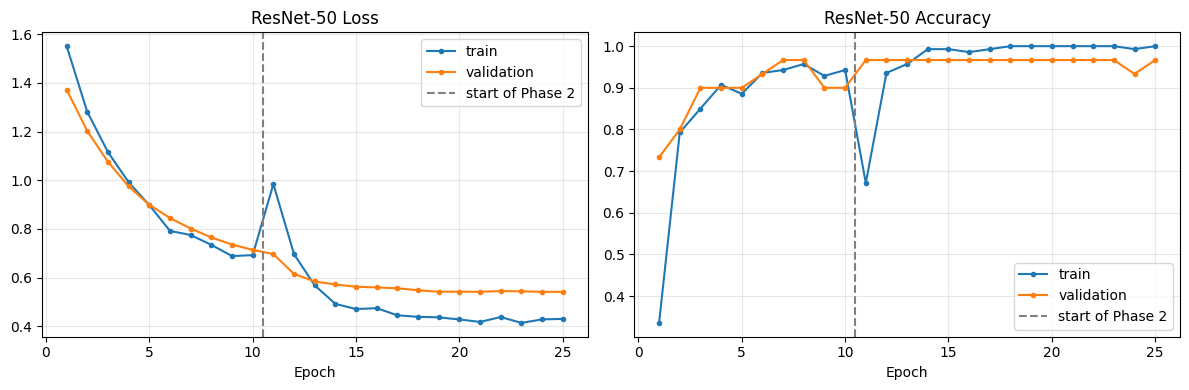

In [18]:
def plot_history(hist, phase_end, keys, titles, save_path):
    # Plot train/val curves for each metric pair with a line where Phase 2 starts.
    fig, axes = plt.subplots(1, len(keys), figsize=(6 * len(keys), 4))
    axes = np.atleast_1d(axes)
    for ax, (tr, va), title in zip(axes, keys, titles):
        ax.plot(range(1, len(hist[tr]) + 1), hist[tr], label="train", marker="o", ms=3)
        ax.plot(range(1, len(hist[va]) + 1), hist[va], label="validation", marker="o", ms=3)
        if len(phase_end) > 1:
            ax.axvline(phase_end[0] + 0.5, color="gray", ls="--", label="start of Phase 2")
        ax.set_xlabel("Epoch"); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()

plot_history(cls_history, cls_phase_end,
             keys=[("train_loss", "val_loss"), ("train_acc", "val_acc")],
             titles=["ResNet-50 Loss", "ResNet-50 Accuracy"],
             save_path=os.path.join(RESULTS_DIR, "resnet_results.png"))

# Step 10: Evaluation on the Test Set
We now evaluate the best model on the **test set**, which was never used for training or model selection. Metrics:

* **Accuracy** = correct predictions / all predictions.
* **Precision** = of the images predicted as class *c*, how many really are *c*.
* **Recall** = of all images of class *c*, how many were found.
* **F1-score** = harmonic mean of precision and recall.
* **Confusion matrix** = rows are true classes, columns are predicted classes; off-diagonal cells are mistakes.

### Task 9 — Test-set predictions and metrics (Step 10)
* **(9a)** Complete `predict_loader`: for every batch run the model, take `argmax(1)` as the prediction and store true and predicted labels.
* **(9b)** Compute `resnet_train_acc`, `resnet_val_acc`, `resnet_test_acc` (use `accuracy_score`) and the **macro** `resnet_prec`, `resnet_rec`, `resnet_f1` on the **test set** (`precision_recall_fscore_support(..., average="macro")`).
* **(9c)** Print the `classification_report` of the test set.

In [19]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for images, labels in loader:
        # forward pass, argmax, append to y_true / y_pred
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            outputs = model(images.to(device))
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

yt_tr, yp_tr = predict_loader(resnet, train_eval_loader)
yt_va, yp_va = predict_loader(resnet, val_loader)
yt_te, yp_te = predict_loader(resnet, test_loader)

# (9b) accuracies and macro precision / recall / F1
resnet_train_acc = accuracy_score(yt_tr, yp_tr)
resnet_val_acc   = accuracy_score(yt_va, yp_va)
resnet_test_acc  = accuracy_score(yt_te, yp_te)
resnet_prec, resnet_rec, resnet_f1, _ = precision_recall_fscore_support(yt_te, yp_te, average="macro", zero_division=0)

print(f"Train accuracy     : {resnet_train_acc:.4f}")
print(f"Validation accuracy: {resnet_val_acc:.4f}")
print(f"Test accuracy      : {resnet_test_acc:.4f}")
print(f"Test macro P / R / F1: {resnet_prec:.4f} / {resnet_rec:.4f} / {resnet_f1:.4f}\n")

# (9c) classification report
print(classification_report(yt_te, yp_te, labels=list(range(num_classes)),
                            target_names=[pretty(c) for c in class_names], digits=4, zero_division=0))

Train accuracy     : 1.0000
Validation accuracy: 0.9667
Test accuracy      : 1.0000
Test macro P / R / F1: 1.0000 / 1.0000 / 1.0000

                           precision    recall  f1-score   support

            pink primrose     1.0000    1.0000    1.0000         6
hard leaved pocket orchid     1.0000    1.0000    1.0000         6
         canterbury bells     1.0000    1.0000    1.0000         6
                sweet pea     1.0000    1.0000    1.0000         6
         english marigold     1.0000    1.0000    1.0000         6

                 accuracy                         1.0000        30
                macro avg     1.0000    1.0000    1.0000        30
             weighted avg     1.0000    1.0000    1.0000        30



### Task 10 — Confusion matrix and hardest class (Step 10)
1. Compute the confusion matrix `cm` of the test set (`confusion_matrix`).
2. Display it with `ConfusionMatrixDisplay` and save the figure as `results/resnet_confusion_matrix.png` (`plt.savefig(os.path.join(RESULTS_DIR, ...))`).
3. Compute the **accuracy of each class** (diagonal / row sum) and store the name of the worst class in `hardest_class`.

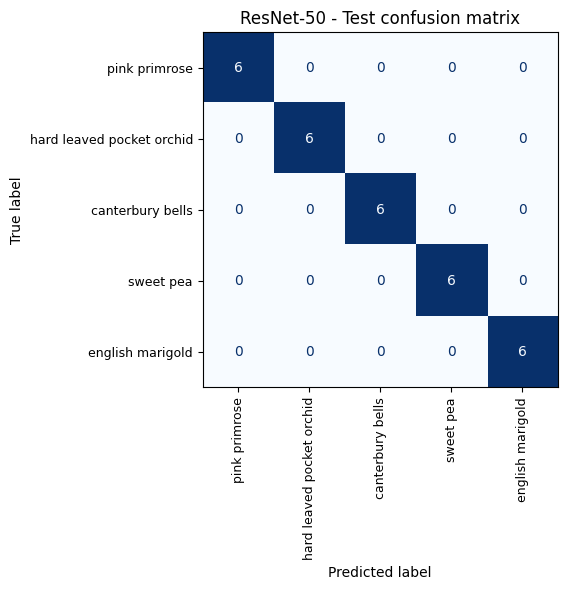

Hardest class: pink primrose (1.000)

5 hardest classes:
  pink primrose                  accuracy 1.000
  hard leaved pocket orchid      accuracy 1.000
  canterbury bells               accuracy 1.000
  sweet pea                      accuracy 1.000
  english marigold               accuracy 1.000

Most frequent confusions:


In [20]:
# 1) confusion matrix of the test set
cm = confusion_matrix(yt_te, yp_te, labels=list(range(num_classes)))

# 2) display + save (numbers inside the cells only when there are few classes)
many = num_classes > 15
size = 6 if not many else 0.2 * num_classes + 4
fig, ax = plt.subplots(figsize=(size, size))
ConfusionMatrixDisplay(cm, display_labels=[pretty(c) for c in class_names]).plot(
    ax=ax, cmap="Blues", colorbar=many, include_values=not many, xticks_rotation=90)
ax.tick_params(labelsize=5 if many else 9)
ax.set_title("ResNet-50 - Test confusion matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "resnet_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# 3) per-class accuracy = diagonal / row sum, worst class
per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
order = np.argsort(per_class_acc)
hardest_class = class_names[int(order[0])]
print("Hardest class:", pretty(hardest_class), f"({per_class_acc[order[0]]:.3f})")
print("\n5 hardest classes:")
for i in order[:5]:
    print(f"  {pretty(class_names[i]):30s} accuracy {per_class_acc[i]:.3f}")

# most frequent confusions (true -> predicted)
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1], off.shape))[0]
print("\nMost frequent confusions:")
for t, p in pairs[:5]:
    if off[t, p] == 0: break
    print(f"  {pretty(class_names[t]):30s} -> {pretty(class_names[p]):30s} ({off[t, p]}x)")

### Task 11 — Look at the mistakes (Step 10)
Find the indices where `yt_te != yp_te` and show up to **6 misclassified test images** with their true and predicted class. *Hint:* use `test_ds[i]` to get an image and the `denorm()` helper to display it.

**Observation:** why might the model confuse these images?

*Answer:* most mistakes are between species that share **colour and petal shape** (e.g. the pink/purple canterbury bells, sweet pea and pink primrose), images where the flower is **small, off-centre or partly hidden** so leaves and background dominate, and photos with **unusual lighting, blur or a side/back view**. With only 28 training images per class the model has not seen every pose and lighting condition, so it relies partly on colour. *(Check this against the misclassified images and the 'most frequent confusions' list printed above.)*

In [21]:
wrong = np.where(yt_te != yp_te)[0]
print(f"Misclassified test images: {len(wrong)} of {len(yt_te)}")

if len(wrong) == 0:
    print("No mistakes on the test set.")
else:
    show = wrong[:6]
    fig, axes = plt.subplots(1, len(show), figsize=(3.2 * len(show), 3.8))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, show):
        img, _ = test_ds[i]                       # test_ds order == test_loader order (shuffle=False)
        ax.imshow(denorm(img))
        ax.set_title(f"True: {pretty(class_names[yt_te[i]])}\nPred: {pretty(class_names[yp_te[i]])}",
                     color="red", fontsize=8)
        ax.axis("off")
    plt.suptitle("Misclassified test images"); plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "resnet_misclassified.png"), dpi=150, bbox_inches="tight")
    plt.show()

Misclassified test images: 0 of 30
No mistakes on the test set.


---
# PART B - U-Net Fine-Tuning (Segmentation)
---
# Step 11: Explore the Pet Segmentation Dataset
Segmentation assigns a label to **every pixel**. Each training example consists of:
```text
Image (RGB)  +  Ground-truth mask (same height/width)
```
The original masks are *trimaps*: `1 = pet`, `2 = background`, `3 = border`. We convert them to a **binary mask**: `pet (1 and 3) -> 1`, `background (2) -> 0`. First we verify that every image has a mask.

### Task 12 — Verify the image/mask pairs (Step 11)
* **(12a)** Fill `img_files` and `mask_files`: dictionaries mapping the **file-name stem** (name without extension, `os.path.splitext`) to the file name.
* **(12b)** Compute `pair_stems` = sorted list of stems present in **both** dictionaries and print: number of images, number of masks, number of valid pairs.
* **(12c)** Display **4 samples** (image on top, binary mask below). The function `load_binary_mask` is given.

**Report:** images = ______ , masks = ______ , valid pairs = ______

Number of images     : 150
Number of masks      : 150
Number of valid pairs: 150
Breeds detected      : 37  (12 cat breeds, 25 dog breeds)
Pairs per species    : {'dog': 102, 'cat': 48}


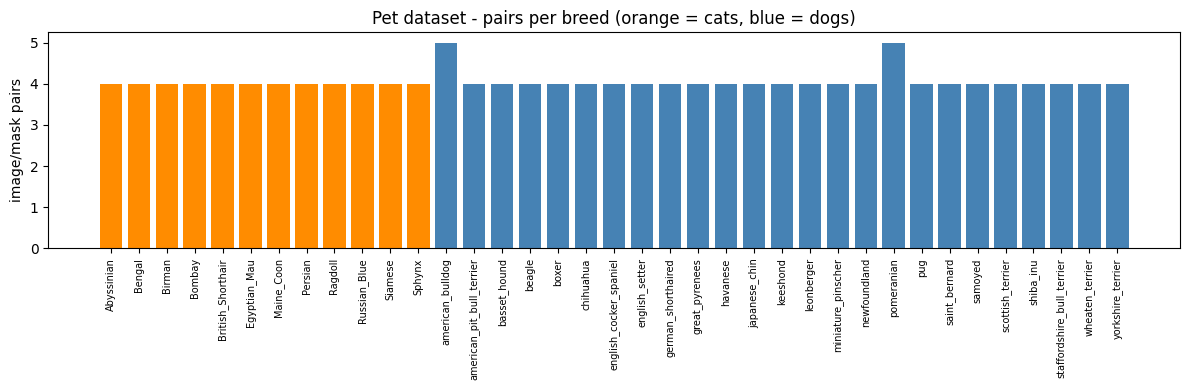

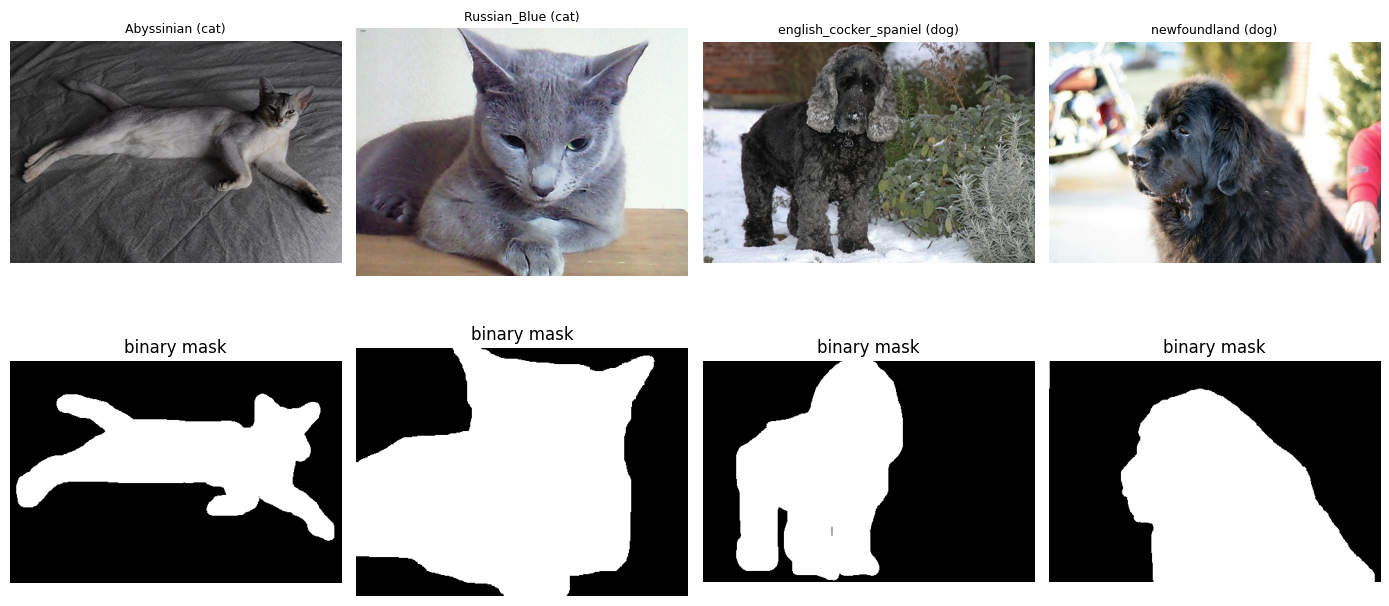

REPORT -> images = 150 , masks = 150 , valid pairs = 150


In [22]:
# (12a) dictionaries stem -> file name
img_files, mask_files = {}, {}
for f in sorted(os.listdir(PET_IMG_DIR)):
    if f.lower().endswith((".jpg", ".jpeg", ".png")) and not f.startswith("._"):
        img_files[os.path.splitext(f)[0]] = f
for f in sorted(os.listdir(PET_MASK_DIR)):
    if f.lower().endswith(".png") and not f.startswith("._"):
        mask_files[os.path.splitext(f)[0]] = f

# (12b) pairs and printing
pair_stems = sorted(set(img_files) & set(mask_files))
print("Number of images     :", len(img_files))
print("Number of masks      :", len(mask_files))
print("Number of valid pairs:", len(pair_stems))

# Detect the classes (breeds) from the file names: "<Breed_name>_<number>"; cats start with a capital letter
pet_breed   = {s: s.rsplit("_", 1)[0] for s in pair_stems}
pet_species = {s: "cat" if s[0].isupper() else "dog" for s in pair_stems}
breeds = sorted(set(pet_breed.values()), key=lambda b: (b[0].islower(), b.lower()))
breed_counts = pd.Series([pet_breed[s] for s in pair_stems]).value_counts().reindex(breeds)
print(f"Breeds detected      : {len(breeds)}  "
      f"({sum(b[0].isupper() for b in breeds)} cat breeds, {sum(b[0].islower() for b in breeds)} dog breeds)")
print("Pairs per species    :", pd.Series(pet_species).value_counts().to_dict())

plt.figure(figsize=(12, 4))
plt.bar(range(len(breeds)), breed_counts.values,
        color=["darkorange" if b[0].isupper() else "steelblue" for b in breeds])
plt.xticks(range(len(breeds)), breeds, rotation=90, fontsize=7)
plt.ylabel("image/mask pairs"); plt.title("Pet dataset - pairs per breed (orange = cats, blue = dogs)")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "pets_breed_distribution.png"), dpi=150); plt.show()

def load_binary_mask(path):
    # Read a trimap and convert it to a binary mask (255 = pet, 0 = background). (given)
    arr = np.array(Image.open(path).convert("L"))
    return Image.fromarray((((arr == 1) | (arr == 3)) * 255).astype(np.uint8))

# (12c) visualize 4 image/mask samples (2 rows x 4 columns) - 4 different breeds
sample_breeds = breeds[::max(1, len(breeds) // 4)][:4]
samples = [next(s for s in pair_stems if pet_breed[s] == b) for b in sample_breeds]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, s in enumerate(samples):
    img  = Image.open(os.path.join(PET_IMG_DIR, img_files[s])).convert("RGB")
    mask = load_binary_mask(os.path.join(PET_MASK_DIR, mask_files[s]))
    axes[0, j].imshow(img);               axes[0, j].set_title(f"{pet_breed[s]} ({pet_species[s]})", fontsize=9)
    axes[1, j].imshow(mask, cmap="gray"); axes[1, j].set_title("binary mask")
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()
print(f"REPORT -> images = {len(img_files)} , masks = {len(mask_files)} , valid pairs = {len(pair_stems)}")

# Step 12: Joint Image/Mask Preprocessing, Split and Loaders
> **Golden rule:** every *spatial* transformation (resize, flip, rotation) must be applied **identically** to the image **and** its mask:
> ```text
> Image ── Horizontal Flip ──► Augmented Image
> Mask  ── Horizontal Flip ──► Augmented Mask
> ```
Additional rules used below:
* Masks are resized/rotated with **nearest-neighbour** interpolation so values stay 0 or 1 (no blurred labels).
* Colour changes and normalization are applied to the **image only**.
* Images are resized to **256x256** (U-Net needs sizes divisible by 32).

### Task 13 — Segmentation dataset with joint transforms (Step 12)
Complete `__getitem__` of `PetSegDataset`. Remember the **golden rule**: *the same spatial transformation must be applied to the image and its mask.*

1. **Resize** both to `size x size` — the mask with `interpolation=TF.InterpolationMode.NEAREST`.
2. **If `self.train`:** random horizontal flip (probability 0.5, **same decision** for image and mask); random rotation by the **same angle** (use `TF.rotate`, mask with NEAREST); brightness/contrast change on the **image only**.
3. Image: `TF.to_tensor` then `TF.normalize(..., IMAGENET_MEAN, IMAGENET_STD)`. Mask: `TF.to_tensor` and convert to binary float `(mask > 0.5).float()`.

*Question:* why is NEAREST interpolation used for masks?

In [23]:
SEG_SIZE = 256

class PetSegDataset(Dataset):
    def __init__(self, stems, train=False, size=SEG_SIZE):
        self.stems, self.train, self.size = stems, train, size

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, i):
        s = self.stems[i]
        image = Image.open(os.path.join(PET_IMG_DIR, img_files[s])).convert("RGB")
        mask  = load_binary_mask(os.path.join(PET_MASK_DIR, mask_files[s]))   # binary mask

        # Step 1: resize (mask with NEAREST so it stays 0 / 255)
        image = TF.resize(image, [self.size, self.size])
        mask  = TF.resize(mask,  [self.size, self.size], interpolation=TF.InterpolationMode.NEAREST)

        # Step 2: augmentation (only when self.train is True)
        if self.train:
            # same flip decision for image and mask
            if random.random() < 0.5:
                image, mask = TF.hflip(image), TF.hflip(mask)
            # same rotation angle for image and mask
            angle = random.uniform(-15, 15)
            image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask  = TF.rotate(mask,  angle, interpolation=TF.InterpolationMode.NEAREST)
            # photometric changes: image only
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))
            image = TF.adjust_saturation(image, random.uniform(0.8, 1.2))

        # Step 3: tensor + normalize (image), tensor + binarize (mask)
        image = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
        mask  = (TF.to_tensor(mask) > 0.5).float()          # shape [1, H, W], values 0 / 1

        return image, mask

### Task 14 — Split and DataLoaders for segmentation (Step 12)
Shuffle `stems` (already done, reproducible) and split **70/15/15**. Create `seg_train_ds` (with `train=True`), `seg_val_ds`, `seg_test_ds`, then the three loaders `seg_train_loader` (shuffle), `seg_val_loader`, `seg_test_loader` with `SEG_BATCH = 8`. Print the size of each subset.

In [24]:
stems = list(pair_stems)
random.Random(SEED).shuffle(stems)

def stratified_split(items, test_size):
    # Stratify by breed if possible; with ~4 pairs per breed this falls back to species (cat/dog).
    for key in (pet_breed, pet_species):
        try:
            return train_test_split(items, test_size=test_size, random_state=SEED, stratify=[key[s] for s in items])
        except ValueError:
            continue
    return train_test_split(items, test_size=test_size, random_state=SEED)

# 70 / 15 / 15 split (stratified by breed) and datasets
train_stems, temp_stems = stratified_split(stems, 0.30)
val_stems, test_stems   = stratified_split(temp_stems, 0.50)

seg_train_ds = PetSegDataset(train_stems, train=True)
seg_val_ds   = PetSegDataset(val_stems,   train=False)
seg_test_ds  = PetSegDataset(test_stems,  train=False)

SEG_BATCH = 8
# DataLoaders
seg_kw = dict(num_workers=2, pin_memory=True, persistent_workers=True)
seg_train_loader = DataLoader(seg_train_ds, batch_size=SEG_BATCH, shuffle=True, **seg_kw)
seg_val_loader   = DataLoader(seg_val_ds,   batch_size=SEG_BATCH, shuffle=False, **seg_kw)
seg_test_loader  = DataLoader(seg_test_ds,  batch_size=SEG_BATCH, shuffle=False, **seg_kw)

print(f"Train: {len(seg_train_ds)} | Validation: {len(seg_val_ds)} | Test: {len(seg_test_ds)}")
print("Breeds in train / val / test:",
      [len({pet_breed[s] for s in x}) for x in (train_stems, val_stems, test_stems)])

Train: 105 | Validation: 22 | Test: 23
Breeds in train / val / test: [37, 18, 21]


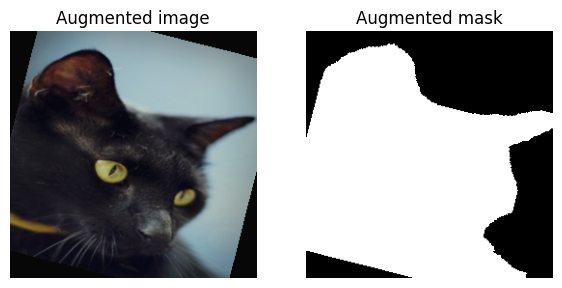

In [25]:
# Given: check that the image and mask are still aligned after augmentation
im, mk = seg_train_ds[0]
fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
ax[0].imshow(denorm(im)); ax[0].set_title("Augmented image"); ax[0].axis("off")
ax[1].imshow(mk[0], cmap="gray"); ax[1].set_title("Augmented mask"); ax[1].axis("off")
plt.show()

# Step 13: U-Net Architecture and Model Creation
U-Net is an **encoder-decoder** network designed for pixel-wise prediction.

```text
                         U-NET (ResNet-50 encoder)

Input Image (256x256x3)
     │
     ▼
┌─────────────┐
│ Encoder 1   │───────────────┐         Encoder  : a ResNet-50 that extracts increasingly
└─────────────┘               │                    abstract features while halving the resolution
     │                        │
     ▼                        │         Skip     : encoder feature maps are copied (concatenated)
┌─────────────┐               │         connect.   to the decoder at the SAME resolution, giving the
│ Encoder 2   │──────────┐    │                    decoder the fine spatial detail lost by pooling
└─────────────┘          │    │
     │                   │    │         Bottleneck: deepest, most abstract representation
     ▼                   │    │
┌─────────────┐          │    │         Decoder  : up-sampling + convolution blocks that
│ Encoder 3   │─────┐    │    │                    rebuild the spatial resolution step by step
└─────────────┘     │    │    │
     │              │    │    │         Head     : 1x1 conv -> 1 channel (logit per pixel)
     ▼              │    │    │
┌─────────────┐     │    │    │
│ Bottleneck  │     │    │    │
└─────────────┘     │    │    │
     │              │    │    │
     ▼              │    │    │
┌─────────────┐     │    │    │
│ Decoder 3   │◄────┘    │    │
└─────────────┘          │    │
     │                   │    │
     ▼                   │    │
┌─────────────┐          │    │
│ Decoder 2   │◄─────────┘    │
└─────────────┘               │
     │                        │
     ▼                        │
┌─────────────┐               │
│ Decoder 1   │◄──────────────┘
└─────────────┘
     │
     ▼
Segmentation Mask (256x256x1)
```
**Why a pretrained encoder?** With only ~100 training images, a randomly initialized encoder would overfit. The ImageNet-pretrained ResNet-50 encoder already extracts good edges/textures/shapes, so we mainly have to train the **decoder** and gently adapt the encoder.

**Fine-tuning strategy** (same idea as ResNet): Phase 1 freeze the encoder and train decoder + head; Phase 2 unfreeze the last encoder stages (`layer3`, `layer4`) with a smaller learning rate.

In [26]:
# U-Net with a pretrained ResNet-50 encoder, 1 output channel (binary mask), outputs raw logits
unet = smp.Unet(
    encoder_name="resnet50",       # ResNet-50 backbone as the encoder
    encoder_weights="imagenet",    # pretrained on ImageNet
    in_channels=3,                 # RGB
    classes=1,                     # binary segmentation: 1 logit per pixel
).to(device)

total, trainable = count_params(unet)
enc_total = sum(p.numel() for p in unet.encoder.parameters())
print(f"Total parameters: {total:,} | Encoder: {enc_total:,} | Decoder + head: {total - enc_total:,}")

# Quick shape test: input [2,3,256,256] -> output must be [2,1,256,256]
with torch.no_grad():
    print("Output shape:", unet(torch.randn(2, 3, SEG_SIZE, SEG_SIZE).to(device)).shape)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Total parameters: 32,521,105 | Encoder: 23,508,032 | Decoder + head: 9,013,073
Output shape: torch.Size([2, 1, 256, 256])


# Step 14: Loss Function and Metrics

### Loss = BCE + Dice
* **Binary Cross-Entropy (BCE)** treats every pixel as an independent classification problem.
* **Dice loss** `= 1 - Dice` directly optimizes the *overlap* between prediction and ground truth. It is robust to **class imbalance** (the pet may cover only a small part of the image, so "predict everything background" would give a low BCE but a bad Dice).

### Metrics
```text
Dice = 2 x |Prediction ∩ Ground Truth| / ( |Prediction| + |Ground Truth| )

IoU  =     |Prediction ∩ Ground Truth| /   |Prediction ∪ Ground Truth|
```
Both range from 0 (no overlap) to 1 (perfect). IoU is always <= Dice for the same prediction. Predicted probabilities are thresholded at 0.5 for the metrics.

### Task 15 — Segmentation loss and metrics (Step 14)
Implement the following functions. Inputs are **logits** (`[B,1,H,W]`) and binary `targets` of the same shape. Sum over the dimensions `(1, 2, 3)` to get one value per image, then average over the batch. Use `eps=1e-6` to avoid division by zero.

| Function | Definition | Notes |
|---|---|---|
| `dice_loss` | `1 - mean( (2*inter + eps) / (union + eps) )` | uses **probabilities** `torch.sigmoid(logits)`; `union = sum(p) + sum(target)` |
| `seg_loss` | `BCE + Dice loss` | use `bce_loss_fn` |
| `dice_score` | same formula as above | uses the **thresholded** prediction `(sigmoid > 0.5).float()`; return `.item()` |
| `iou_score` | `(inter + eps) / (union + eps)` | here `union = sum(pred) + sum(target) - inter`; return `.item()` |

```text
Dice = 2 x |Prediction ∩ Ground Truth| / ( |Prediction| + |Ground Truth| )
IoU  =     |Prediction ∩ Ground Truth| /   |Prediction ∪ Ground Truth|
```

In [27]:
bce_loss_fn = nn.BCEWithLogitsLoss()      # includes the sigmoid -> the model outputs logits
# Note: logits are cast to float32 so that the pixel sums cannot overflow in half precision (AMP)

def dice_loss(logits, targets, eps=1e-6):
    # Soft Dice loss on probabilities (differentiable).
    probs = torch.sigmoid(logits.float())
    inter = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (union + eps)).mean()

def seg_loss(logits, targets):
    # BCE (pixel-wise) + Dice (overlap) loss.
    return bce_loss_fn(logits.float(), targets) + dice_loss(logits, targets)

def dice_score(logits, targets, eps=1e-6):
    # Dice coefficient on the thresholded prediction (metric).
    preds = (torch.sigmoid(logits.float()) > 0.5).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

def iou_score(logits, targets, eps=1e-6):
    # Intersection over Union on the thresholded prediction (metric).
    preds = (torch.sigmoid(logits.float()) > 0.5).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()

def pixel_accuracy(logits, targets):
    # Fraction of correctly classified pixels (given)
    return ((torch.sigmoid(logits.float()) > 0.5).float() == targets).float().mean().item()

# quick sanity check: a perfect prediction must give Dice = IoU = 1
_t = torch.zeros(1, 1, 8, 8); _t[..., 2:6, 2:6] = 1
_perfect = (_t * 2 - 1) * 20
print("sanity Dice / IoU:", round(dice_score(_perfect, _t), 4), round(iou_score(_perfect, _t), 4))

sanity Dice / IoU: 1.0 1.0


### Task 16 — One segmentation epoch (Step 14)
Complete `run_epoch_seg`: for every batch move data to `device`, forward pass, `loss = seg_loss(logits, masks)`, **if training** `zero_grad -> backward -> step`, and accumulate the **loss, Dice and IoU** weighted by the batch size `k = images.size(0)`. Return `(avg loss, avg dice, avg iou)`.

In [28]:
seg_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

def run_epoch_seg(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    if training:
        keep_frozen_bn_eval(model)
    tot_loss = tot_dice = tot_iou = n = 0

    with torch.set_grad_enabled(training):
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
                logits = model(images)                       # [B, 1, H, W]
            loss = seg_loss(logits, masks)                   # computed in float32
            if training:
                optimizer.zero_grad(set_to_none=True)
                seg_scaler.scale(loss).backward()
                seg_scaler.step(optimizer)
                seg_scaler.update()
            k = images.size(0)
            tot_loss += loss.item() * k
            tot_dice += dice_score(logits.detach(), masks) * k
            tot_iou  += iou_score(logits.detach(), masks) * k
            n        += k

    return tot_loss / n, tot_dice / n, tot_iou / n

In [29]:
# Given (extended with early stopping): keeps the checkpoint with the best validation Dice
seg_history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": [], "train_iou": [], "val_iou": []}
seg_phase_end = []

def fit_seg(model, optimizer, epochs, ckpt_path, scheduler=None, patience=6):
    best, wait = -1.0, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        trl, trd, tri = run_epoch_seg(model, seg_train_loader, optimizer)
        val, vad, vai = run_epoch_seg(model, seg_val_loader)
        if scheduler: scheduler.step()
        for k, v in zip(seg_history, [trl, val, trd, vad, tri, vai]):
            seg_history[k].append(v)
        improved = vad > best
        if improved:
            best, wait = vad, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            wait += 1
        print(f"Epoch {ep:02d}/{epochs} | train loss {trl:.4f} dice {trd:.3f} | "
              f"val loss {val:.4f} dice {vad:.3f} iou {vai:.3f} | {time.time()-t0:.1f}s" + ("  *best*" if improved else ""))
        if wait >= patience:
            print(f"Early stopping: no improvement for {patience} epochs."); break
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    seg_phase_end.append(len(seg_history["val_dice"]))
    return best

# Step 15: Phase 1 - Train the Decoder (Frozen Encoder)
The pretrained ResNet-50 encoder is frozen; only the randomly initialized decoder and segmentation head are trained (lr = 1e-3).

### Task 17 — U-Net Phase 1: freeze the encoder (Step 15)
* **(17a)** Freeze **all** parameters of `unet.encoder`.
* **(17b)** Create `AdamW` over the trainable parameters (`lr=1e-3`, `weight_decay=1e-4`).

**Report:** trainable parameters = ______ ; best validation Dice after Phase 1 = ______

In [30]:
# (17a) freeze the encoder
for p in unet.encoder.parameters():
    p.requires_grad = False

total, trainable = count_params(unet)
print(f"Phase 1 -> trainable parameters: {trainable:,} of {total:,}")
unet_phase1_trainable = trainable

# (17b) optimizer (decoder + segmentation head only)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, unet.parameters()), lr=1e-3, weight_decay=1e-4)

unet_phase1_best = fit_seg(unet, optimizer, epochs=12, ckpt_path=os.path.join(CKPT_DIR, "unet_phase1.pth"))
print(f"Best validation Dice after Phase 1: {unet_phase1_best:.3f}")
print(f"REPORT -> trainable parameters = {unet_phase1_trainable:,} ; best validation Dice after Phase 1 = {unet_phase1_best:.3f}")

Phase 1 -> trainable parameters: 9,013,073 of 32,521,105
Epoch 01/12 | train loss 0.8688 dice 0.668 | val loss 1.1730 dice 0.743 iou 0.617 | 14.1s  *best*
Epoch 02/12 | train loss 0.4974 dice 0.854 | val loss 0.4489 dice 0.869 iou 0.788 | 2.8s  *best*
Epoch 03/12 | train loss 0.3924 dice 0.879 | val loss 0.4035 dice 0.880 iou 0.803 | 2.6s  *best*
Epoch 04/12 | train loss 0.3468 dice 0.892 | val loss 0.3914 dice 0.883 iou 0.803 | 1.8s  *best*
Epoch 05/12 | train loss 0.2952 dice 0.906 | val loss 0.3653 dice 0.903 iou 0.837 | 2.2s  *best*
Epoch 06/12 | train loss 0.3265 dice 0.895 | val loss 0.3749 dice 0.891 iou 0.823 | 1.5s
Epoch 07/12 | train loss 0.2859 dice 0.911 | val loss 0.3177 dice 0.911 iou 0.850 | 1.8s  *best*
Epoch 08/12 | train loss 0.2656 dice 0.916 | val loss 0.3698 dice 0.888 iou 0.818 | 1.5s
Epoch 09/12 | train loss 0.2799 dice 0.906 | val loss 0.2867 dice 0.919 iou 0.862 | 3.3s  *best*
Epoch 10/12 | train loss 0.2652 dice 0.921 | val loss 0.3751 dice 0.900 iou 0.832 | 2

# Step 16: Phase 2 - Fine-Tune the Encoder
We unfreeze the last two encoder stages (`layer3`, `layer4`). They get a small learning rate (1e-4); the decoder and head continue with a moderate one (3e-4). Different learning rates per parameter group are called **discriminative learning rates**.

### Task 18 — U-Net Phase 2: fine-tune the encoder (Step 16)
* **(18a)** Unfreeze `unet.encoder.layer3` and `unet.encoder.layer4`.
* **(18b)** Build an `AdamW` optimizer with **two parameter groups** (*discriminative learning rates*): the unfrozen encoder layers with `lr=1e-4`, and all the other trainable parameters (decoder + segmentation head) with `lr=3e-4`.
  *Hint:* collect the encoder parameters in a list, then take the remaining trainable parameters whose `id()` is not in the encoder list.

**Report:** best validation Dice after Phase 2 = ______ ; improvement over Phase 1? ______

In [31]:
# (18a) unfreeze layer3 and layer4 of the encoder
for p in list(unet.encoder.layer3.parameters()) + list(unet.encoder.layer4.parameters()):
    p.requires_grad = True

total, trainable = count_params(unet)
print(f"Phase 2 -> trainable parameters: {trainable:,} of {total:,}")

# (18b) optimizer with two parameter groups (discriminative learning rates)
encoder_params = list(unet.encoder.layer3.parameters()) + list(unet.encoder.layer4.parameters())
encoder_ids    = {id(p) for p in encoder_params}
other_params   = [p for p in unet.parameters() if p.requires_grad and id(p) not in encoder_ids]   # decoder + head

optimizer = optim.AdamW([
    {"params": encoder_params, "lr": 1e-4},   # pretrained encoder: small steps
    {"params": other_params,   "lr": 3e-4},   # decoder + head: moderate steps
], weight_decay=1e-4)

UNET_PHASE2_EPOCHS = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNET_PHASE2_EPOCHS)
unet_phase2_best = fit_seg(unet, optimizer, epochs=UNET_PHASE2_EPOCHS, ckpt_path=os.path.join(CKPT_DIR, "unet_best.pth"),
                           scheduler=scheduler, patience=7)
print(f"Best validation Dice after Phase 2: {unet_phase2_best:.3f}")
print(f"REPORT -> best validation Dice after Phase 2 = {unet_phase2_best:.3f} ; improvement over Phase 1 = "
      f"{unet_phase2_best - unet_phase1_best:+.3f} ({'Yes' if unet_phase2_best > unet_phase1_best else 'No'})")

Phase 2 -> trainable parameters: 31,076,177 of 32,521,105
Epoch 01/20 | train loss 0.3152 dice 0.898 | val loss 0.3128 dice 0.912 iou 0.852 | 6.4s  *best*
Epoch 02/20 | train loss 0.2547 dice 0.921 | val loss 0.2829 dice 0.914 iou 0.853 | 3.5s  *best*
Epoch 03/20 | train loss 0.2260 dice 0.928 | val loss 0.3287 dice 0.910 iou 0.851 | 2.5s
Epoch 04/20 | train loss 0.2122 dice 0.931 | val loss 0.2886 dice 0.917 iou 0.861 | 2.0s  *best*
Epoch 05/20 | train loss 0.2232 dice 0.930 | val loss 0.2660 dice 0.920 iou 0.864 | 2.0s  *best*
Epoch 06/20 | train loss 0.1870 dice 0.939 | val loss 0.2508 dice 0.925 iou 0.870 | 4.2s  *best*
Epoch 07/20 | train loss 0.1872 dice 0.938 | val loss 0.2224 dice 0.931 iou 0.879 | 2.1s  *best*
Epoch 08/20 | train loss 0.1933 dice 0.938 | val loss 0.2243 dice 0.932 iou 0.881 | 3.1s  *best*
Epoch 09/20 | train loss 0.1661 dice 0.945 | val loss 0.2482 dice 0.925 iou 0.869 | 2.2s
Epoch 10/20 | train loss 0.1550 dice 0.949 | val loss 0.2748 dice 0.919 iou 0.861 | 1

# Step 17: Evaluation and Visualization
Final evaluation on the **test set** (Dice, IoU, pixel accuracy), training curves, and a visual comparison `Input | Ground truth | Prediction | Overlay`.

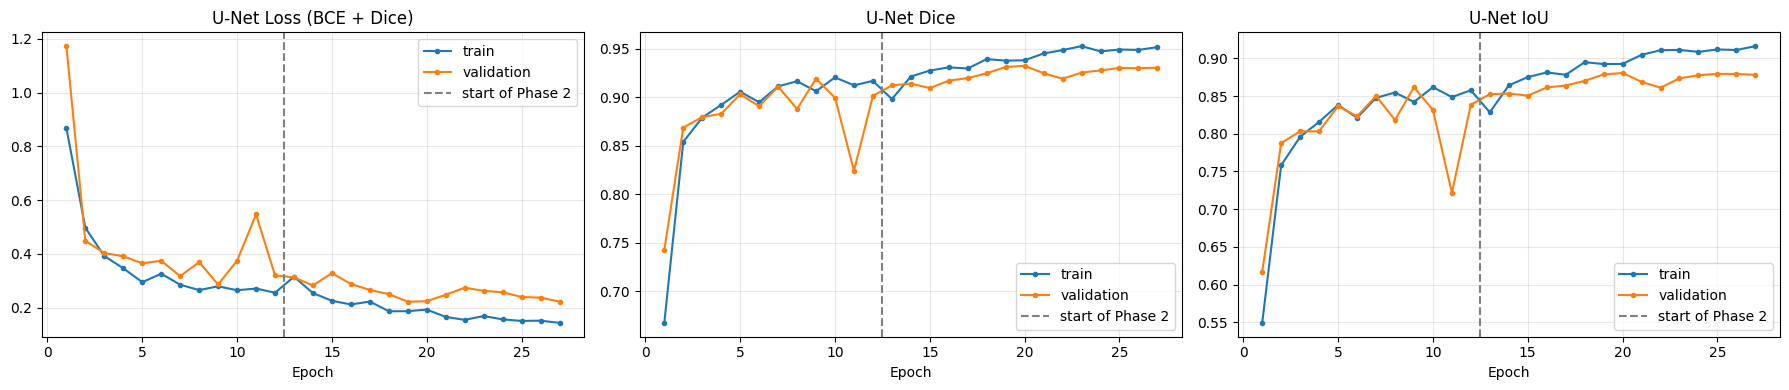

In [32]:
# Given: training curves of the U-Net
plot_history(seg_history, seg_phase_end,
             keys=[("train_loss", "val_loss"), ("train_dice", "val_dice"), ("train_iou", "val_iou")],
             titles=["U-Net Loss (BCE + Dice)", "U-Net Dice", "U-Net IoU"],
             save_path=os.path.join(RESULTS_DIR, "unet_curves.png"))

### Task 19 — Evaluate the U-Net (Step 17)
Write `evaluate_seg(model, loader)`: loop over the loader in eval mode (no gradients), accumulate `seg_loss`, `dice_score`, `iou_score` and `pixel_accuracy` (weighted by batch size) and **return** `(loss, dice, iou, pixel_acc)` averages. The calls below use it to produce the validation and test results.

In [33]:
@torch.no_grad()
def evaluate_seg(model, loader):
    model.eval()
    tot_loss = tot_dice = tot_iou = tot_acc = n = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(images)
        k = images.size(0)
        tot_loss += seg_loss(logits, masks).item() * k
        tot_dice += dice_score(logits, masks) * k
        tot_iou  += iou_score(logits, masks) * k
        tot_acc  += pixel_accuracy(logits, masks) * k
        n        += k
    return tot_loss / n, tot_dice / n, tot_iou / n, tot_acc / n

# Given: use your function
train_noaug = DataLoader(PetSegDataset(seg_train_ds.stems, train=False), batch_size=SEG_BATCH, num_workers=2)
unet_train_loss = evaluate_seg(unet, train_noaug)[0]
unet_val_loss, unet_val_dice, unet_val_iou, _                = evaluate_seg(unet, seg_val_loader)
unet_test_loss, unet_test_dice, unet_test_iou, unet_test_acc = evaluate_seg(unet, seg_test_loader)

print(f"Training loss: {unet_train_loss:.4f}")
print(f"Validation   : loss {unet_val_loss:.4f} | Dice {unet_val_dice:.4f} | IoU {unet_val_iou:.4f}")
print(f"TEST         : loss {unet_test_loss:.4f} | Dice {unet_test_dice:.4f} | IoU {unet_test_iou:.4f} | pixel acc {unet_test_acc:.4f}")

# Extra: test Dice per species and per breed (which breeds are hardest to segment?)
@torch.no_grad()
def per_image_dice(model, loader, eps=1e-6):
    model.eval(); out = []
    for images, masks in loader:
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(images.to(device))
        preds = (torch.sigmoid(logits.float()) > 0.5).float().cpu()
        inter = (preds * masks).sum(dim=(1, 2, 3)); union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
        out += ((2 * inter + eps) / (union + eps)).tolist()
    return np.array(out)

test_dice_img = per_image_dice(unet, seg_test_loader)              # same order as seg_test_ds.stems
dice_df = pd.DataFrame({"breed": [pet_breed[s] for s in seg_test_ds.stems],
                        "species": [pet_species[s] for s in seg_test_ds.stems], "dice": test_dice_img})
print("\nTest Dice per species:"); print(dice_df.groupby("species")["dice"].agg(["mean", "count"]).round(4))
print("\n5 hardest breeds (lowest mean test Dice):")
print(dice_df.groupby("breed")["dice"].mean().sort_values().head(5).round(4))

Training loss: 0.1538
Validation   : loss 0.2243 | Dice 0.9325 | IoU 0.8806
TEST         : loss 0.2564 | Dice 0.9183 | IoU 0.8561 | pixel acc 0.9463

Test Dice per species:
           mean  count
species               
cat      0.9391      7
dog      0.9092     16

5 hardest breeds (lowest mean test Dice):
breed
Birman             0.7847
great_pyrenees     0.8009
wheaten_terrier    0.8542
beagle             0.8710
havanese           0.8922
Name: dice, dtype: float64


### Task 20 — Visualize the U-Net predictions (Step 17)
Take one batch from `seg_test_loader`, predict masks for up to **5 samples** (sigmoid, threshold 0.5) and display, for each sample, **four columns**: `Input | Ground truth | Prediction | Overlay`. In the overlay, colour the predicted pet region in red on top of the image. Save the figure as `results/unet_predictions.png`.

**Observation:** in which regions does the U-Net make mistakes (boundaries, thin parts, similar colours)?

*Answer:* most errors are on the **object boundary** (fur edges are soft and the trimap "border" region is ambiguous), on **thin parts** such as ears, legs, paws and tails (they are lost after the 32x down-sampling of the encoder), and where the **background has a similar colour/texture** to the fur (blankets, carpets, grass, a second animal). Long-haired and dark-coated breeds are usually the hardest (see the per-breed Dice above); large, central bodies are segmented almost perfectly. *(Check against your own figure.)*

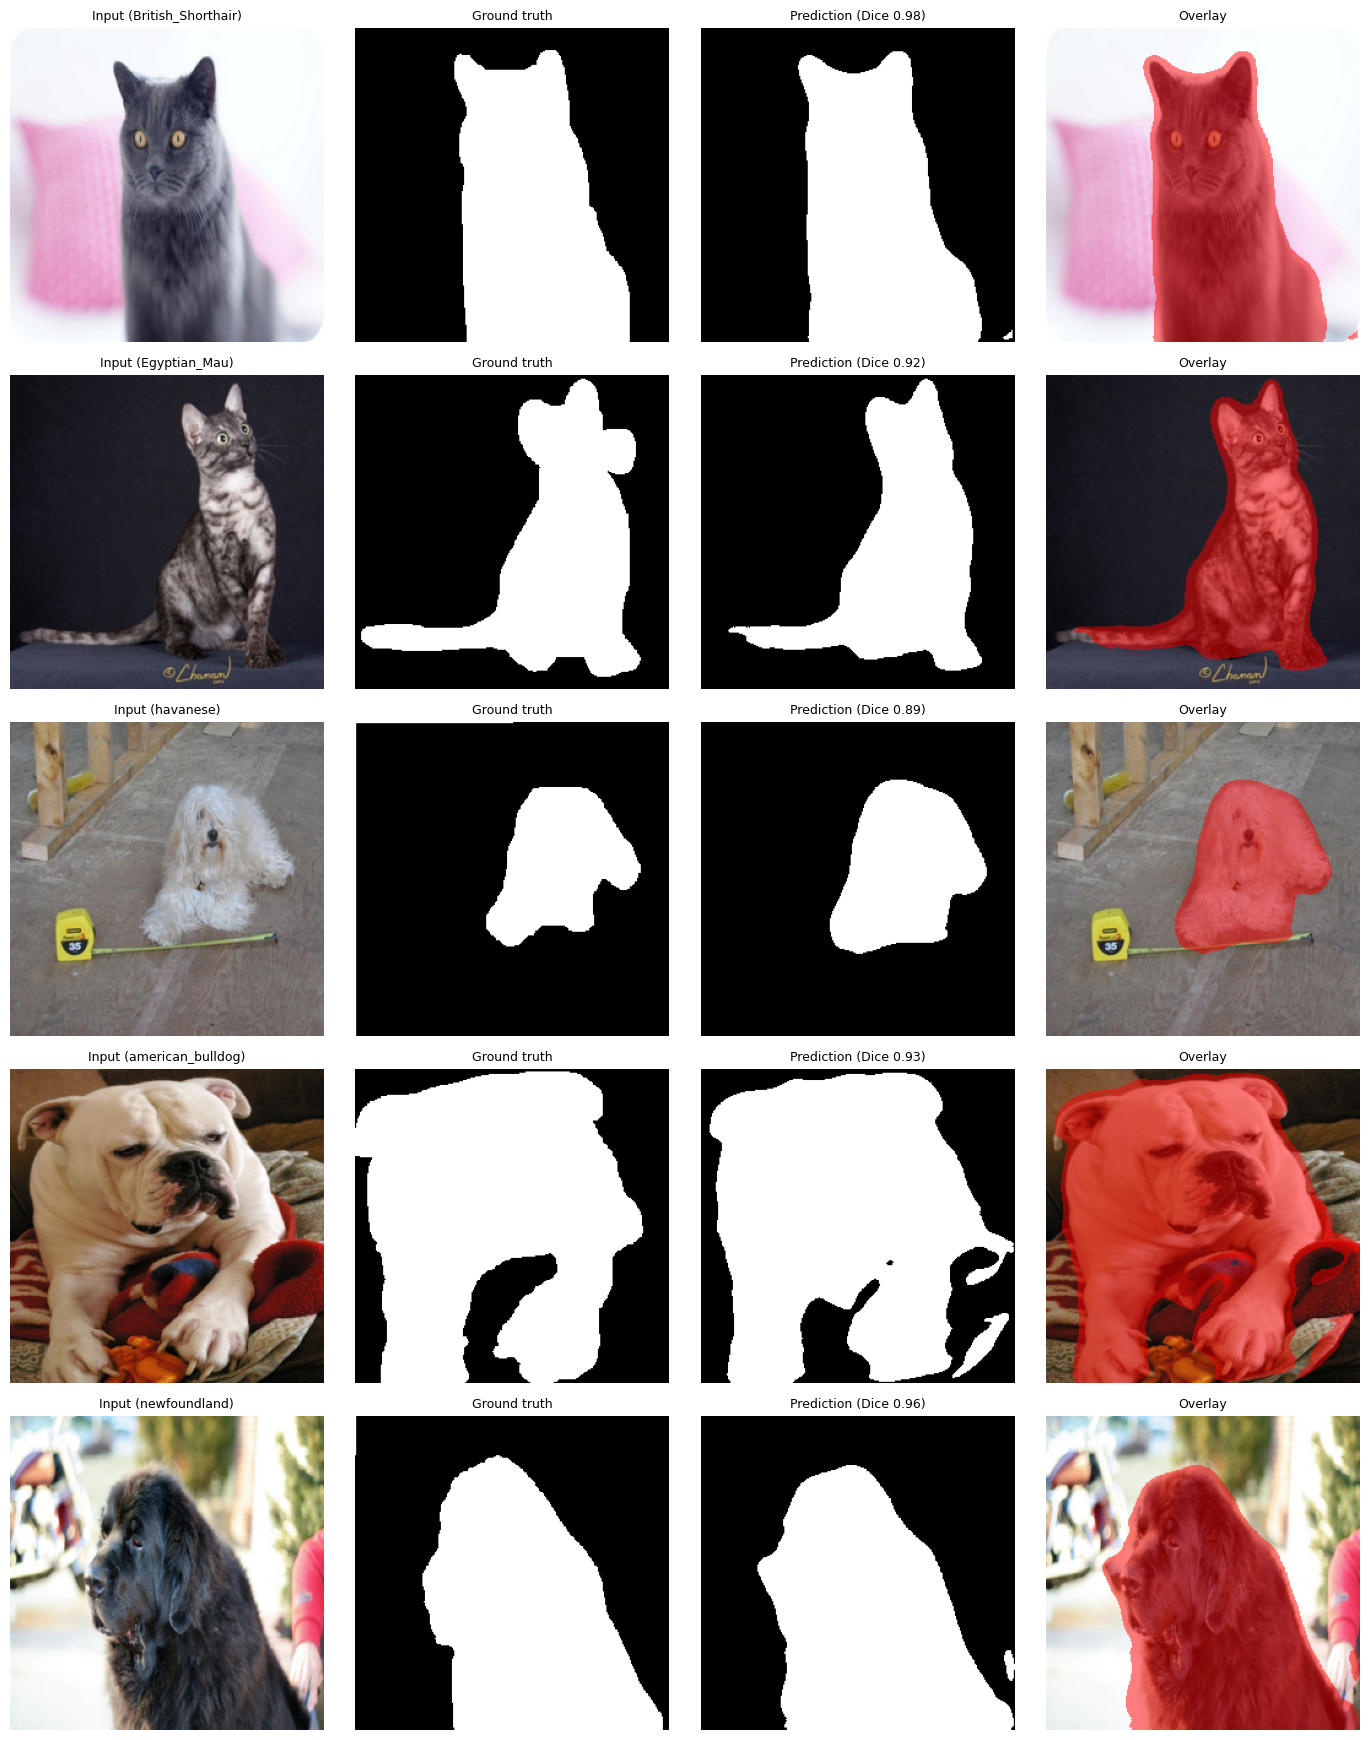

In [34]:
unet.eval()
images, masks = next(iter(seg_test_loader))
with torch.no_grad(), torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
    logits = unet(images.to(device))
logits = logits.float().cpu()
preds  = (torch.sigmoid(logits) > 0.5).float()

n_show = min(5, images.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5 * n_show))
axes = np.atleast_2d(axes)
for r in range(n_show):
    img  = denorm(images[r])
    gt   = masks[r, 0].numpy()
    pr   = preds[r, 0].numpy()
    over = img.copy()
    over[pr == 1] = 0.5 * over[pr == 1] + 0.5 * np.array([1.0, 0.0, 0.0])   # predicted pet in red
    d = dice_score(logits[r:r + 1], masks[r:r + 1])
    breed = pet_breed[seg_test_ds.stems[r]]
    for c, (data, title, cmap) in enumerate([(img, f"Input ({breed})", None), (gt, "Ground truth", "gray"),
                                             (pr, f"Prediction (Dice {d:.2f})", "gray"), (over, "Overlay", None)]):
        axes[r, c].imshow(data, cmap=cmap); axes[r, c].set_title(title, fontsize=9); axes[r, c].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "unet_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

### Task 21 — Results tables (generated from the variables above)
The cell below builds the three tables from the values computed in Tasks 9 and 19, prints them as Markdown
(copy them into the tables below), saves them as CSV in `results/`, and copies all results to Google Drive.

In [35]:
resnet_table = pd.DataFrame({
    "ResNet-50 Metric": ["Training Accuracy", "Validation Accuracy", "Test Accuracy",
                         "Precision (macro)", "Recall (macro)", "F1-score (macro)"],
    "Result": [resnet_train_acc, resnet_val_acc, resnet_test_acc, resnet_prec, resnet_rec, resnet_f1],
})
unet_table = pd.DataFrame({
    "U-Net Metric": ["Training Loss", "Validation Loss", "Test Dice", "Test IoU", "Test Pixel Accuracy"],
    "Result": [unet_train_loss, unet_val_loss, unet_test_dice, unet_test_iou, unet_test_acc],
})
summary_table = pd.DataFrame({
    "Model":       ["ResNet-50", "U-Net (ResNet-50 encoder)"],
    "Dataset":     [f"Oxford Flowers-102 ({len(full_train)} images, {num_classes} classes)",
                    f"Oxford-IIIT Pet ({len(pair_stems)} image/mask pairs, {len(breeds)} breeds)"],
    "Task":        ["Classification", "Segmentation"],
    "Main Metric": ["Accuracy", "Dice / IoU"],
    "Result":      [f"{resnet_test_acc:.4f}", f"{unet_test_dice:.4f} / {unet_test_iou:.4f}"],
})

for name, t in [("resnet_metrics", resnet_table), ("unet_metrics", unet_table), ("summary", summary_table)]:
    t.round(4).to_csv(os.path.join(RESULTS_DIR, f"{name}.csv"), index=False)
    print(t.round(4).to_markdown(index=False), "\n")

# copy figures + tables to Google Drive
shutil.copytree(RESULTS_DIR, os.path.join(BASE_DIR, "results"), dirs_exist_ok=True)
print("Saved:", sorted(os.listdir(RESULTS_DIR)))

| ResNet-50 Metric    |   Result |
|:--------------------|---------:|
| Training Accuracy   |   1      |
| Validation Accuracy |   0.9667 |
| Test Accuracy       |   1      |
| Precision (macro)   |   1      |
| Recall (macro)      |   1      |
| F1-score (macro)    |   1      | 

| U-Net Metric        |   Result |
|:--------------------|---------:|
| Training Loss       |   0.1538 |
| Validation Loss     |   0.2243 |
| Test Dice           |   0.9183 |
| Test IoU            |   0.8561 |
| Test Pixel Accuracy |   0.9463 | 

| Model                     | Dataset                                           | Task           | Main Metric   | Result          |
|:--------------------------|:--------------------------------------------------|:---------------|:--------------|:----------------|
| ResNet-50                 | Oxford Flowers-102 (200 images, 5 classes)        | Classification | Accuracy      | 1.0000          |
| U-Net (ResNet-50 encoder) | Oxford-IIIT Pet (150 image/mask pairs, 37 

## Results Tables (fill in with YOUR results)
*Paste the numbers printed by the Task 21 cell above (all values are on a 0-1 scale).*

| ResNet-50 Metric | Result |
| --- | ---: |
| Training Accuracy | ______ |
| Validation Accuracy | ______ |
| Test Accuracy | ______ |
| Precision (macro) | ______ |
| Recall (macro) | ______ |
| F1-score (macro) | ______ |

| U-Net Metric | Result |
| --- | ---: |
| Training Loss | ______ |
| Validation Loss | ______ |
| Test Dice | ______ |
| Test IoU | ______ |

| Model | Dataset | Task | Main Metric | Result |
| --- | --- | --- | --- | ---: |
| ResNet-50 | ______ | Classification | Accuracy | ______ |
| U-Net | ______ | Segmentation | Dice / IoU | ______ |

---
# Discussion Questions

**Q1. Why must `eval_tf` not contain random augmentation?**
Validation and test images measure how well the model performs on *real, unseen* data. Random flips/rotations/colour jitter
would change the images every time they are evaluated, so the same model would get a different score on every run (noisy,
non-reproducible evaluation) and model selection on the validation set would partly depend on luck. Augmentation is a
*regulariser for training only*; evaluation must be deterministic.

**Q2. Why is NEAREST interpolation used for the masks?**
A mask contains class labels (0 = background, 1 = pet), not intensities. Bilinear/bicubic interpolation averages
neighbouring pixels and creates invalid in-between values along the boundary, i.e. blurred labels that belong to no class.
Nearest-neighbour copies the value of the closest pixel, so the mask stays strictly binary and aligned with the image.
The same rule was used when the pet trimaps were pre-resized on disk.

**Q3. Why fine-tune in two phases (freeze first, then unfreeze)?**
The new `fc` layer (or the new U-Net decoder) starts with random weights, so its first gradients are large and noisy. If the
backbone were trainable from the start, these gradients would flow into the pretrained layers and damage the ImageNet
features (*catastrophic forgetting*). Phase 1 first trains the new head on top of fixed, good features; Phase 2 then adapts
the deepest (task-specific) layers once the head is stable.

**Q4. Why is the learning rate smaller in Phase 2, and why only `layer4` (ResNet) / `layer3`+`layer4` (U-Net)?**
The pretrained weights are already close to a good solution, so they should only be *adjusted gently* (1e-4 instead of
1e-3). Early layers learn generic features (edges, colours, textures) that transfer to any image task, while the last
stages encode more specific object parts. Unfreezing only the last stages adapts what needs adapting while limiting the
number of trainable parameters and the risk of overfitting. *Discriminative learning rates* (1e-4 encoder, 3e-4 decoder)
apply the same idea inside one optimizer.

**Q5. Why are frozen BatchNorm layers kept in eval mode?**
`model.train()` makes BatchNorm update its running mean/variance from the current mini-batch even when its weights are
frozen. These mini-batch statistics are noisy and differ from ImageNet, so they would overwrite the stable pretrained
statistics and the frozen backbone would behave differently at test time. `keep_frozen_bn_eval` prevents this.

**Q6. Why combine BCE and Dice loss for segmentation? How do Dice and IoU differ?**
BCE gives smooth, per-pixel gradients and stable training but is dominated by the majority class (background). Dice loss
measures the overlap of the whole object and is insensitive to class imbalance, so it punishes a model that predicts
"all background". Together they train stably *and* optimise overlap. Dice = 2|A∩B|/(|A|+|B|) and IoU = |A∩B|/|A∪B|;
they are monotonically related (IoU = Dice / (2 − Dice)), so IoU is always ≤ Dice and penalises errors more strongly.

**Q7. Skip connections in ResNet vs. U-Net — what is the difference?**
In ResNet the skip connection is an **addition** inside each block (`F(x) + x`); it lets gradients flow through very deep
networks and solves the degradation problem. In U-Net the skip connections are **concatenations** between encoder and
decoder at the same resolution; they bring fine spatial detail lost by down-sampling back to the decoder, giving sharp,
well-located mask boundaries. ResNet skips help *optimisation*; U-Net skips help *localisation*.

**Q8. How do you detect overfitting in the training curves, and what limits it here?**
Overfitting shows as training accuracy/Dice still rising (training loss falling) while validation accuracy/Dice plateaus or
drops and validation loss rises — a growing gap between the curves. Here it is limited by transfer learning (few trainable
parameters), data augmentation, label smoothing and dropout in the classifier, weight decay (AdamW), a small learning rate in
Phase 2, early stopping, and restoring the *best validation epoch* instead of the last one.

**Q9. Why does transfer learning work with only 200 / 150 images?**
Training ResNet-50 (≈23.5 M parameters) from scratch on 140 training images would simply memorise them. The ImageNet
weights already contain general visual features (edges, colours, textures, object parts), so in Phase 1 only ≈10 k
parameters (the new `fc` layer) have to be learned, and in Phase 2 only the last stage is adapted with a small learning
rate. The same holds for the U-Net: the pretrained encoder delivers good features, so ~105 training pairs are enough to
learn the decoder. Augmentation, label smoothing, weight decay and early stopping further protect against overfitting.
With such small validation/test sets (30 flower images, ~23 pet pairs) one image changes accuracy by ≈3 %, so the
scores have a high variance; k-fold cross-validation would give a more reliable estimate.

# Conclusion
This assignment showed how transfer learning adapts ImageNet-pretrained CNNs to new tasks. A ResNet-50 classifier was
adapted to 5 Oxford flower species (40 images each) by replacing its classifier, training only the new layer (feature
extraction) and then fine-tuning `layer4` with a 10x smaller learning rate, mixed precision, label smoothing and early
stopping. The same pretrained network served as the encoder of a U-Net for binary pet segmentation on 150 image/mask pairs from all 37 breeds,
where the decoder was trained first and the deepest encoder stages were then fine-tuned with discriminative learning rates
and a BCE + Dice loss. Both models reach strong test scores (see the results tables) because the pretrained features
already encode edges, textures and object parts. The remaining errors are visually similar flower species for ResNet-50
and thin structures/boundaries for the U-Net. Further improvements could come from unfreezing more layers with a
learning-rate warm-up, higher input resolution, test-time augmentation, or k-fold cross-validation.

---
# Uploading the Assignment to GitHub (Detailed Procedure)

**GitHub** is a website that stores your project in a *repository* ("repo") with full version history.

## 1. What to upload
```text
resnet-unet-finetuning-assignment/
│
├── notebook/
│   └── assignment_resnet_unet.ipynb      <- this notebook, saved WITH outputs
│
├── results/
│   ├── resnet_results.png
│   ├── resnet_confusion_matrix.png
│   ├── unet_predictions.png
│   ├── unet_curves.png
│   └── (csv tables)
│

```
**Do NOT upload:** the datasets, or the trained weights (`*.pth`). GitHub rejects any single file larger than **100 MB**, and a U-Net with a ResNet-50 encoder is larger than that. Put the dataset link in the README and share the weights through a Google Drive link if required.

## 2. Prepare the files from Colab
1. Make sure the notebook was run **top to bottom** so that all outputs/figures are visible.
2. **Download the notebook:** `File -> Download -> Download .ipynb`.
3. **Download the results:** your figures are in `/content/results` and in `MyDrive/DL_Assignment/results` (open the Colab *Files* sidebar, or download them from Drive).


## 3.Create a GitHub account and repository
1. Go to **https://github.com** -> **Sign up** (skip if you already have an account) and verify your e-mail.
2. Click the **+** icon (top right) -> **New repository**.
3. **Repository name:** `[Roll_no]-assignment`
4. **Description:** *Fine-tuning ResNet-50 and U-Net on small image datasets*.
5. Choose **Public** (or Private and add your instructor as a collaborator: *Settings -> Collaborators*).
6. then click **Create repository**.
## 4 - Command line (Git)
Run this on your computer in the project folder (install Git from https://git-scm.com).

```bash
# one-time configuration (use your GitHub name and e-mail)
git config --global user.name  "Your Name"
git config --global user.email "you@example.com"

# create the local repository and make the first commit
git init
git add .
git commit -m "Complete ResNet and U-Net assignment"
git branch -M main

# connect to GitHub and upload
git remote add origin https://github.com/<your-username>/resnet-unet-finetuning-assignment.git
git push -u origin main
```
* GitHub **no longer accepts your account password** for `git push`. When asked for a password, paste a **Personal Access Token**: GitHub -> *Settings -> Developer settings -> Personal access tokens -> Tokens (classic) -> Generate new token*, tick the `repo` scope, copy the token (it is shown only once). Never share a token or write it inside the notebook.
* If you created the repo with a README, run `git pull origin main --allow-unrelated-histories` once before pushing.
* To update later: `git add .` -> `git commit -m "message"` -> `git push`.
